# **NETWORK INTRUSION DETECTION SYSTEM**



# Multinomial Classification (normal or DOS or PROBE or R2L or U2R)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
import itertools
import seaborn as sns

import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

In [ ]:
from sklearn import datasets
from sklearn.feature_selection import RFE
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train=pd.read_csv('/content/drive/MyDrive/ML_Lab/Train.txt',sep=',')
test=pd.read_csv('/content/drive/MyDrive/ML_Lab/Test.txt',sep=',')

In [ ]:
train.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [ ]:
columns=["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
         "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations",
         "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate",
         "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
         "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
         "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
         "dst_host_srv_rerror_rate","attack","last_flag"]

In [ ]:
len(columns)

43

In [ ]:
train.columns=columns
test.columns=columns

In [ ]:
train = train.dropna()
train

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125968,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [ ]:
test

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22539,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21


In [ ]:

train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [ ]:
test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null  int64  
 13 

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22543 entries, 0 to 22542
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22543 non-null  int64  
 1   protocol_type                22543 non-null  object 
 2   service                      22543 non-null  object 
 3   flag                         22543 non-null  object 
 4   src_bytes                    22543 non-null  int64  
 5   dst_bytes                    22543 non-null  int64  
 6   land                         22543 non-null  int64  
 7   wrong_fragment               22543 non-null  int64  
 8   urgent                       22543 non-null  int64  
 9   hot                          22543 non-null  int64  
 10  num_failed_logins            22543 non-null  int64  
 11  logged_in                    22543 non-null  int64  
 12  num_compromised              22543 non-null  int64  
 13  root_shell      

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125972.0,287.146929,2.604526e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125972.0,45567.100824,5.870354e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125972.0,19779.271433,4.021285e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125972.0,0.000198,1.408613e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125972.0,0.022688,2.535310e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125972.0,0.000111,1.436608e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125972.0,0.204411,2.149977e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125972.0,0.001222,4.523932e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125972.0,0.395739,4.890107e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125972.0,0.279253,2.394214e+01,0.0,0.00,0.00,0.00,7.479000e+03


In attack_class normal means 0, DOS means 1, PROBE means 2, R2L means 3 and U2R means 4.

In [ ]:
# Add this code to the end of the code in 'ipython-input-0-c78372819895' to create the 'attack_class' column in both DataFrames
train['attack_class'] = -1  # Initialize with a placeholder
test['attack_class'] = -1   # Initialize with a placeholder


In [ ]:
train.loc[train.attack=='normal','attack_class']=0

train.loc[(train.attack=='back') | (train.attack=='land') | (train.attack=='pod') | (train.attack=='neptune') |
         (train.attack=='smurf') | (train.attack=='teardrop') | (train.attack=='apache2') | (train.attack=='udpstorm') |
         (train.attack=='processtable') | (train.attack=='worm') | (train.attack=='mailbomb'),'attack_class']=1

train.loc[(train.attack=='satan') | (train.attack=='ipsweep') | (train.attack=='nmap') | (train.attack=='portsweep') |
          (train.attack=='mscan') | (train.attack=='saint'),'attack_class']=2

train.loc[(train.attack=='guess_passwd') | (train.attack=='ftp_write') | (train.attack=='imap') | (train.attack=='phf') |
          (train.attack=='multihop') | (train.attack=='warezmaster') | (train.attack=='warezclient') | (train.attack=='spy') |
          (train.attack=='xlock') | (train.attack=='xsnoop') | (train.attack=='snmpguess') | (train.attack=='snmpgetattack') |
          (train.attack=='httptunnel') | (train.attack=='sendmail') | (train.attack=='named'),'attack_class']=3

train.loc[(train.attack=='buffer_overflow') | (train.attack=='loadmodule') | (train.attack=='rootkit') | (train.attack=='perl') |
          (train.attack=='sqlattack') | (train.attack=='xterm') | (train.attack=='ps'),'attack_class']=4

In [ ]:
test.loc[test.attack=='normal','attack_class']=0

test.loc[(test.attack=='back') | (test.attack=='land') | (test.attack=='pod') | (test.attack=='neptune') |
         (test.attack=='smurf') | (test.attack=='teardrop') | (test.attack=='apache2') | (test.attack=='udpstorm') |
         (test.attack=='processtable') | (test.attack=='worm') | (test.attack=='mailbomb'),'attack_class']=1

test.loc[(test.attack=='satan') | (test.attack=='ipsweep') | (test.attack=='nmap') | (test.attack=='portsweep') |
          (test.attack=='mscan') | (test.attack=='saint'),'attack_class']=2

test.loc[(test.attack=='guess_passwd') | (test.attack=='ftp_write') | (test.attack=='imap') | (test.attack=='phf') |
          (test.attack=='multihop') | (test.attack=='warezmaster') | (test.attack=='warezclient') | (test.attack=='spy') |
          (test.attack=='xlock') | (test.attack=='xsnoop') | (test.attack=='snmpguess') | (test.attack=='snmpgetattack') |
          (test.attack=='httptunnel') | (test.attack=='sendmail') | (test.attack=='named'),'attack_class']=3

test.loc[(test.attack=='buffer_overflow') | (test.attack=='loadmodule') | (test.attack=='rootkit') | (test.attack=='perl') |
          (test.attack=='sqlattack') | (test.attack=='xterm') | (test.attack=='ps'),'attack_class']=4

In [ ]:
# Check unique values in attack_class
print("Unique values in train attack_class:", train['attack_class'].unique())
print("Unique values in test attack_class:", test['attack_class'].unique())


Unique values in train attack_class: [0 1 3 2 4]
Unique values in test attack_class: [1 0 2 3 4]


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le = LabelEncoder()
y_combined = pd.concat([train['attack_class'], test['attack_class']])
le.fit(y_combined)

y_train = le.transform(train['attack_class'])
y_test = le.transform(test['attack_class'])


In [ ]:
from sklearn.preprocessing import StandardScaler

top_features = ['count', 'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate',
                'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
                'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
                'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_rerror_rate']

X_train = train[top_features]
X_test = test[top_features]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1, 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1, 1)


In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert labels to categorical format
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

# Verify shapes
print("X_train_reshaped shape:", X_train_reshaped.shape)
print("y_train_categorical shape:", y_train_categorical.shape)
print("X_test_reshaped shape:", X_test_reshaped.shape)
print("y_test_categorical shape:", y_test_categorical.shape)


X_train_reshaped shape: (125972, 15, 1, 1)
y_train_categorical shape: (125972, 5)
X_test_reshaped shape: (22543, 15, 1, 1)
y_test_categorical shape: (22543, 5)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(X_train_reshaped.shape[1], 1, 1), padding='same'),
    MaxPooling2D(pool_size=(1, 1)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_train_categorical.shape[1], activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_model.fit(X_train_reshaped, y_train_categorical, epochs=10, batch_size=32, validation_data=(X_test_reshaped, y_test_categorical))


Epoch 1/10
3937/3937 [==============================] - 25s 6ms/step - loss: 0.1368 - accuracy: 0.9589 - val_loss: 1.2902 - val_accuracy: 0.7201
Epoch 2/10
3937/3937 [==============================] - 19s 5ms/step - loss: 0.0943 - accuracy: 0.9690 - val_loss: 1.3262 - val_accuracy: 0.7239
Epoch 3/10
3937/3937 [==============================] - 19s 5ms/step - loss: 0.0835 - accuracy: 0.9726 - val_loss: 1.4309 - val_accuracy: 0.7202
Epoch 4/10
3937/3937 [==============================] - 20s 5ms/step - loss: 0.0777 - accuracy: 0.9741 - val_loss: 1.4582 - val_accuracy: 0.7166
Epoch 5/10
3937/3937 [==============================] - 19s 5ms/step - loss: 0.0741 - accuracy: 0.9749 - val_loss: 1.6506 - val_accuracy: 0.7153
Epoch 6/10
3937/3937 [==============================] - 19s 5ms/step - loss: 0.0715 - accuracy: 0.9762 - val_loss: 1.5141 - val_accuracy: 0.7180
Epoch 7/10
3937/3937 [==============================] - 18s 4ms/step - loss: 0.0684 - accuracy: 0.9765 - val_loss: 1.6780 - val_ac

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Define the optimized CNN model
optimized_cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(15, 1, 1), padding='same', kernel_regularizer=l2(0.01)), # L2 regularization
    MaxPooling2D(pool_size=(1, 1)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)), # L2 regularization
    Dropout(0.5),
    Dense(5, activation='softmax')
])

optimized_cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the optimized CNN model with early stopping
optimized_cnn_model.fit(X_train_reshaped, y_train_categorical, epochs=50, batch_size=32, validation_data=(X_test_reshaped, y_test_categorical), callbacks=[early_stopping])

# Evaluate the optimized model
train_loss, train_accuracy = optimized_cnn_model.evaluate(X_train_reshaped, y_train_categorical)
test_loss, test_accuracy = optimized_cnn_model.evaluate(X_test_reshaped, y_test_categorical)

print(f"Train accuracy: {train_accuracy:.4f}, Train loss: {train_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")


Epoch 1/50
3937/3937 [==============================] - 22s 5ms/step - loss: 0.2993 - accuracy: 0.9425 - val_loss: 1.1253 - val_accuracy: 0.7207
Epoch 2/50
3937/3937 [==============================] - 21s 5ms/step - loss: 0.2384 - accuracy: 0.9479 - val_loss: 1.1171 - val_accuracy: 0.7099
Epoch 3/50
3937/3937 [==============================] - 19s 5ms/step - loss: 0.2291 - accuracy: 0.9490 - val_loss: 1.1365 - val_accuracy: 0.7176
Epoch 4/50
3937/3937 [==============================] - 21s 5ms/step - loss: 0.2241 - accuracy: 0.9494 - val_loss: 1.1854 - val_accuracy: 0.7088
Epoch 5/50
3937/3937 [==============================] - 18s 5ms/step - loss: 0.2213 - accuracy: 0.9503 - val_loss: 0.9978 - val_accuracy: 0.7298
Epoch 6/50
3937/3937 [==============================] - 19s 5ms/step - loss: 0.2196 - accuracy: 0.9508 - val_loss: 1.2087 - val_accuracy: 0.7181
Epoch 7/50
3937/3937 [==============================] - 19s 5ms/step - loss: 0.2166 - accuracy: 0.9512 - val_loss: 1.2087 - val_ac

Additional Conv2D and BatchNormalization Layers: Adding more convolutional layers with batch normalization helps the model learn more complex patterns and stabilizes training.
Increased Dropout Rate: Slightly higher dropout rates help to prevent overfitting.
Learning Rate Scheduler: Using ReduceLROnPlateau to decrease the learning rate if the validation loss plateaus. This can help the model converge more smoothly.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the more optimized CNN model
more_optimized_cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(15, 1, 1), padding='same', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(1, 1)),
    Dropout(0.3),

    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(1, 1)),
    Dropout(0.4),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

more_optimized_cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Define learning rate reduction on plateau callback
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# Train the more optimized CNN model with early stopping and learning rate reduction
history = more_optimized_cnn_model.fit(X_train_reshaped, y_train_categorical, epochs=50, batch_size=32,
                                       validation_data=(X_test_reshaped, y_test_categorical),
                                       callbacks=[early_stopping, reduce_lr])

# Evaluate the more optimized model
train_loss, train_accuracy = more_optimized_cnn_model.evaluate(X_train_reshaped, y_train_categorical)
test_loss, test_accuracy = more_optimized_cnn_model.evaluate(X_test_reshaped, y_test_categorical)

print(f"Train accuracy: {train_accuracy:.4f}, Train loss: {train_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")


Epoch 1/50
3937/3937 [==============================] - 62s 15ms/step - loss: 0.4466 - accuracy: 0.9498 - val_loss: 1.2301 - val_accuracy: 0.7019 - lr: 0.0010
Epoch 2/50
3937/3937 [==============================] - 42s 11ms/step - loss: 0.2773 - accuracy: 0.9554 - val_loss: 1.4136 - val_accuracy: 0.7158 - lr: 0.0010
Epoch 3/50
3937/3937 [==============================] - 44s 11ms/step - loss: 0.2649 - accuracy: 0.9554 - val_loss: 1.2272 - val_accuracy: 0.7034 - lr: 0.0010
Epoch 4/50
3937/3937 [==============================] - 43s 11ms/step - loss: 0.2493 - accuracy: 0.9565 - val_loss: 1.4162 - val_accuracy: 0.7039 - lr: 0.0010
Epoch 5/50
3937/3937 [==============================] - 44s 11ms/step - loss: 0.2428 - accuracy: 0.9570 - val_loss: 1.3712 - val_accuracy: 0.7098 - lr: 0.0010
Epoch 6/50
3937/3937 [==============================] - 42s 11ms/step - loss: 0.1818 - accuracy: 0.9637 - val_loss: 1.1061 - val_accuracy: 0.7236 - lr: 5.0000e-04
Epoch 7/50
3937/3937 [====================

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag,attack_class
0,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15,0.0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19,1.0
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21,0.0
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21,0.0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21,1.0


In [ ]:
train.shape

(125972, 44)

### Exporting pandas profiling output to html file

### Basic Exploratory Analysis

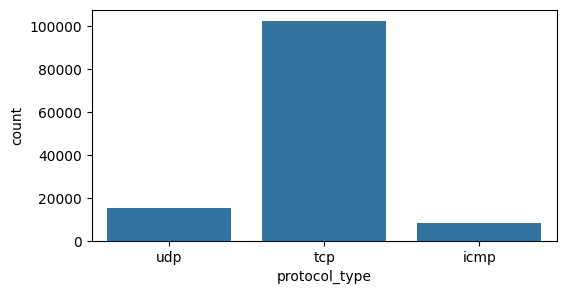

In [ ]:
# Protocol type distribution
plt.figure(figsize=(6,3))
sns.countplot(x="protocol_type", data=train)
plt.show()

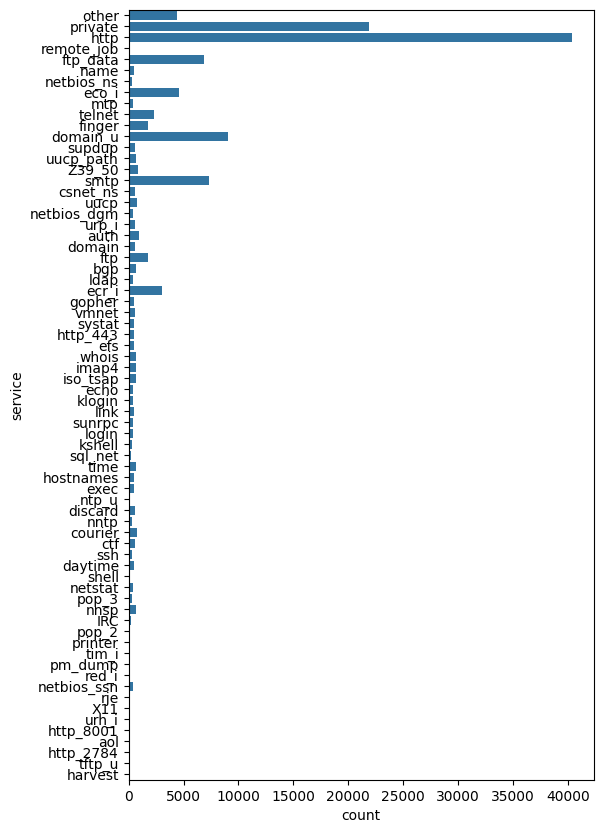

In [ ]:
# service distribution
plt.figure(figsize=(6,10))
sns.countplot(y="service", data=train)
plt.show()

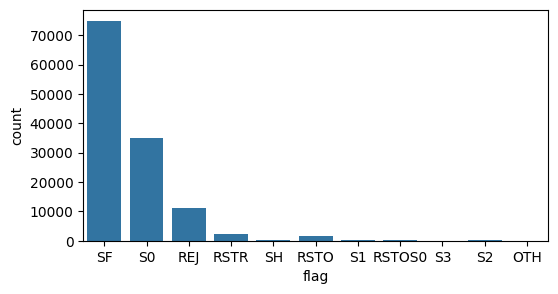

In [ ]:
# flag distribution
plt.figure(figsize=(6,3))
sns.countplot(x="flag", data=train)
plt.show()

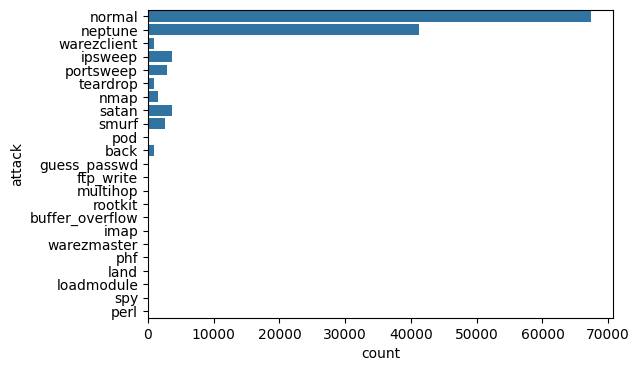

In [ ]:
# attack distribution
plt.figure(figsize=(6,4))
sns.countplot(y="attack", data=train)
plt.show()

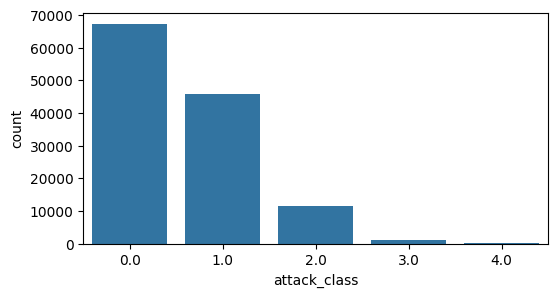

In [ ]:
# attack class distribution
plt.figure(figsize=(6,3))
sns.countplot(x="attack_class", data=train)
plt.show()

#### identifying relationships (between Y & numerical independent variables by comparing means)

In [ ]:
train.groupby('attack_class').mean(numeric_only=True).T

attack_class,0.0,1.0,2.0,3.0,4.0
duration,168.589899,0.006227,2074.858185,633.417085,80.942308
src_bytes,13133.467064,1176.321162,385679.838367,307727.300503,906.230769
dst_bytes,4329.749517,169.201537,181074.911805,81822.026131,5141.961538
land,0.000104,0.000392,0.000000,0.000000,0.000000
wrong_fragment,0.000000,0.062229,0.000000,0.000000,0.000000
urgent,0.000148,0.000000,0.000000,0.003015,0.019231
hot,0.230658,0.039889,0.001630,8.334673,1.403846
num_failed_logins,0.001381,0.000000,0.000343,0.056281,0.019231
logged_in,0.710656,0.020837,0.007121,0.913568,0.884615
num_compromised,0.507083,0.019226,0.000601,0.077387,1.211538


##### Observations:
- The length of time duration of connection for attack is higher than  normal.
- Wrong fragments in the connection is only present in attack.
- Number of outbound commands in an ftp session  are 0 in both normal and attack.

In [ ]:
numeric_var_names=[key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['float64', 'int64', 'float32', 'int32']]
cat_var_names=[key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['object', 'O']]

In [ ]:
numeric_var_names

['duration',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'last_flag',
 'attack_class']

In [ ]:
cat_var_names

['protocol_type', 'service', 'flag', 'attack']

In [ ]:
train_num=train[numeric_var_names]
test_num=test[numeric_var_names]
train_num.head(5)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,last_flag,attack_class
0,0,146,0,0,0,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,15,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,19,1.0
2,0,232,8153,0,0,0,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,21,0.0
3,0,199,420,0,0,0,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,21,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,21,1.0


In [ ]:
train_cat=train[cat_var_names]
test_cat=test[cat_var_names]
train_cat.head(5)

,protocol_type,service,flag,attack
0,udp,other,SF,normal
1,tcp,private,S0,neptune
2,tcp,http,SF,normal
3,tcp,http,SF,normal
4,tcp,private,REJ,neptune


### Data Audit Report

In [ ]:
# Creating Data audit Report
def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.min(), x.dropna().quantile(0.01), x.dropna().quantile(0.05),
                      x.dropna().quantile(0.10),x.dropna().quantile(0.25),x.dropna().quantile(0.50),x.dropna().quantile(0.75), x.dropna().quantile(0.90),
                      x.dropna().quantile(0.95), x.dropna().quantile(0.99),x.max()],
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX'])

num_summary=train_num.apply(lambda x: var_summary(x)).T

In [ ]:
num_summary

,N,NMISS,SUM,MEAN,MEDIAN,STD,VAR,MIN,P1,P5,P10,P25,P50,P75,P90,P95,P99,MAX
duration,125972.0,0.0,3.617247e+07,287.146929,0.00,2.604526e+03,6.783553e+06,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,4.00,9590.58,4.290800e+04
src_bytes,125972.0,0.0,5.740179e+09,45567.100824,44.00,5.870354e+06,3.446106e+13,0.0,0.0,0.00,0.00,0.00,44.00,276.00,848.00,1480.00,54540.00,1.379964e+09
dst_bytes,125972.0,0.0,2.491634e+09,19779.271433,0.00,4.021285e+06,1.617073e+13,0.0,0.0,0.00,0.00,0.00,0.00,516.00,3375.90,8314.00,25519.00,1.309937e+09
land,125972.0,0.0,2.500000e+01,0.000198,0.00,1.408613e-02,1.984190e-04,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125972.0,0.0,2.858000e+03,0.022688,0.00,2.535310e-01,6.427796e-02,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.000000e+00
urgent,125972.0,0.0,1.400000e+01,0.000111,0.00,1.436608e-02,2.063844e-04,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.000000e+00
hot,125972.0,0.0,2.575000e+04,0.204411,0.00,2.149977e+00,4.622401e+00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,7.700000e+01
num_failed_logins,125972.0,0.0,1.540000e+02,0.001222,0.00,4.523932e-02,2.046596e-03,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.000000e+00
logged_in,125972.0,0.0,4.985200e+04,0.395739,0.00,4.890107e-01,2.391315e-01,0.0,0.0,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.000000e+00
num_compromised,125972.0,0.0,3.517800e+04,0.279253,0.00,2.394214e+01,5.732259e+02,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,7.479000e+03


In [ ]:
num_summary.to_csv('num_summary.csv')

### Handling Outlier

In [ ]:
#Handling Outliers
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.99))
    x = x.clip(lower=x.quantile(0.01))
    return x

train_num=train_num.apply(outlier_capping)

#### No missing in train dataset . So , Missing treatment not required .

In [ ]:
def cat_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.value_counts()],
                  index=['N', 'NMISS', 'ColumnsNames'])

cat_summary=train_cat.apply(cat_summary)

In [ ]:
cat_summary

,protocol_type,service,flag,attack
N,125972,125972,125972,125972
NMISS,0,0,0,0
ColumnsNames,protocol_type tcp 102688 udp 14993 ic...,service http 40338 private 21853 ...,flag SF 74944 S0 34851 REJ ...,attack normal 67342 neptune ...


### Dummy Variable Creation

In [ ]:
# An utility function to create dummy variable
def create_dummies( df, colname ):
    col_dummies = pd.get_dummies(df[colname], prefix=colname, drop_first=True)
    df = pd.concat([df, col_dummies], axis=1)
    df.drop( colname, axis = 1, inplace = True )
    return(df)

In [ ]:
#for c_feature in categorical_features
for c_feature in ['protocol_type', 'service', 'flag', 'attack']:
    train_cat = create_dummies(train_cat,c_feature)
    test_cat = create_dummies(test_cat,c_feature)
train_cat.head()

,protocol_type_tcp,protocol_type_udp,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Final file for analysis

In [ ]:
train_new = pd.concat([train_num, train_cat], axis=1)
test_new = pd.concat([test_num, test_cat], axis=1)
train_new.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0.0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0.0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,0.0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
3,0.0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
4,0.0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# correlation matrix (ranges from 1 to -1)
corrm=train_new.corr()
corrm

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
duration,1.000000,0.011740,0.036892,NaN,NaN,NaN,0.021274,NaN,-0.064538,0.062081,...,-0.000757,-0.005534,0.408874,-0.000414,-0.023837,-0.020279,0.000605,-0.011691,0.037013,-0.001571
src_bytes,0.011740,1.000000,0.127827,NaN,NaN,NaN,0.379973,NaN,0.163275,0.603363,...,-0.000898,0.002845,-0.022114,-0.001067,-0.028784,-0.002928,-0.000555,-0.013779,0.047995,-0.002012
dst_bytes,0.036892,0.127827,1.000000,NaN,NaN,NaN,0.127002,NaN,0.421999,0.237363,...,0.010050,-0.014104,-0.053377,0.006873,-0.060374,-0.051676,-0.000156,-0.029791,-0.011541,0.064962
land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wrong_fragment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
attack_smurf,-0.020279,-0.002928,-0.051676,NaN,NaN,NaN,-0.020616,NaN,-0.118539,-0.014876,...,-0.000825,-0.005856,-0.022607,-0.001305,-0.025242,1.000000,-0.000584,-0.012370,-0.012356,-0.001846
attack_spy,0.000605,-0.000555,-0.000156,NaN,NaN,NaN,-0.000561,NaN,0.000850,-0.000405,...,-0.000022,-0.000159,-0.000615,-0.000036,-0.000687,-0.000584,1.000000,-0.000336,-0.000336,-0.000050
attack_teardrop,-0.011691,-0.013779,-0.029791,NaN,NaN,NaN,-0.011886,NaN,-0.068341,-0.008576,...,-0.000476,-0.003376,-0.013034,-0.000752,-0.014553,-0.012370,-0.000336,1.000000,-0.007123,-0.001064
attack_warezclient,0.037013,0.047995,-0.011541,NaN,NaN,NaN,0.270177,NaN,0.104233,-0.008567,...,-0.000475,-0.003372,-0.013019,-0.000752,-0.014536,-0.012356,-0.000336,-0.007123,1.000000,-0.001063


In [ ]:
corrm.to_csv('corrm.csv')

<Axes: >

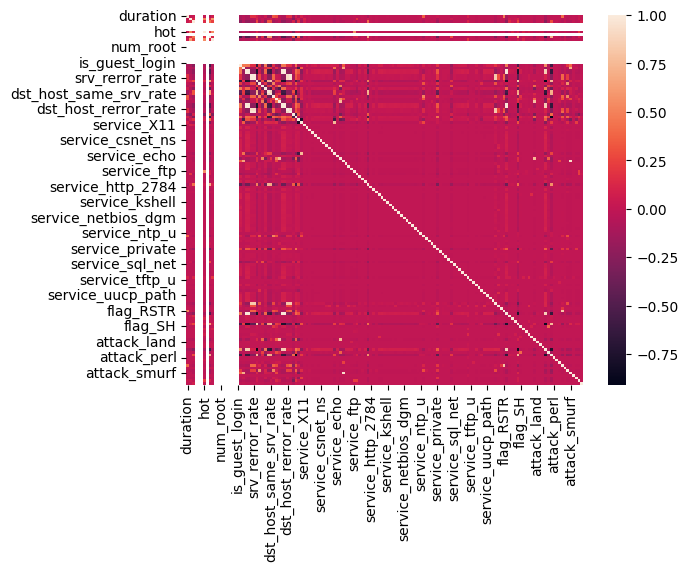

In [ ]:
# visualize correlation matrix in Seaborn using a heatmap
sns.heatmap(corrm)

#### Dropping columns based on data audit report
        - Based on low variance (near zero variance)
        - High missings (>25% missings)
        - High correlations between two numerical variables

In [ ]:
train_new.drop(columns=['land','wrong_fragment','urgent','num_failed_logins',"root_shell","su_attempted","num_root",
                        "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
                        'dst_host_rerror_rate','dst_host_serror_rate','dst_host_srv_rerror_rate','dst_host_srv_serror_rate',
                        'num_root','num_outbound_cmds','srv_rerror_rate','srv_serror_rate'], axis=1, inplace=True)

In [ ]:
train_new["attack_class"]

0         0.0
1         1.0
2         0.0
3         0.0
4         1.0
         ... 
125967    1.0
125968    0.0
125969    0.0
125970    1.0
125971    0.0
Name: attack_class, Length: 125972, dtype: float64

<Axes: >

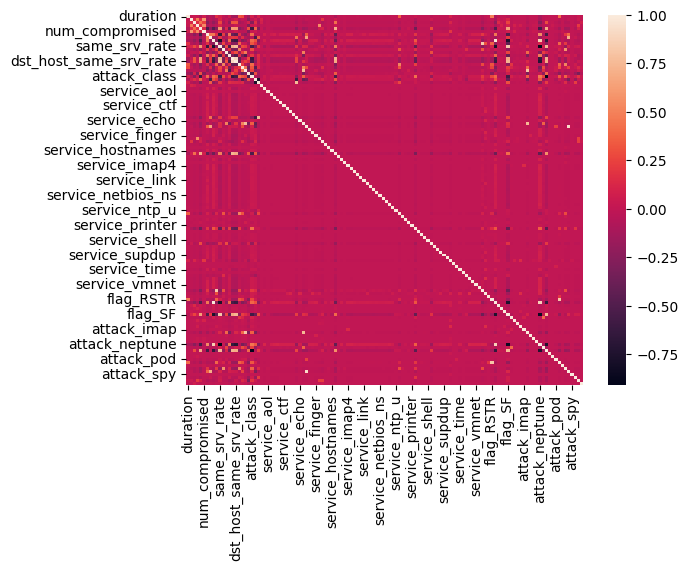

In [ ]:
sns.heatmap(train_new.corr())

#### Variable reduction using Select K-Best technique

In [ ]:
X = train_new[train_new.columns.difference(['attack_class'])]
X

,attack_buffer_overflow,attack_ftp_write,attack_guess_passwd,attack_imap,attack_ipsweep,attack_land,attack_loadmodule,attack_multihop,attack_neptune,attack_nmap,...,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,src_bytes,srv_count,srv_diff_host_rate
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,146,1,0.00
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,0,6,0.00
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,232,5,0.00
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,199,32,0.09
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,0,19,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,0,25,0.00
125968,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,105,2,0.00
125969,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,2231,1,0.00
125970,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,0,8,0.00


In [ ]:
X = X.dropna()
X

,attack_buffer_overflow,attack_ftp_write,attack_guess_passwd,attack_imap,attack_ipsweep,attack_land,attack_loadmodule,attack_multihop,attack_neptune,attack_nmap,...,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,src_bytes,srv_count,srv_diff_host_rate
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,146,1,0.00
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,0,6,0.00
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,232,5,0.00
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,199,32,0.09
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,0,19,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,0,25,0.00
125968,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,105,2,0.00
125969,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,2231,1,0.00
125970,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,0,8,0.00


In [ ]:
train_new = train_new.dropna()
train_new

,duration,src_bytes,dst_bytes,hot,logged_in,num_compromised,count,srv_count,serror_rate,rerror_rate,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0.0,146,0,0,0,0,13,1,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,0.0,0,0,0,0,0,123,6,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,0.0,232,8153,0,1,0,5,5,0.2,0.0,...,False,False,False,False,False,False,False,False,False,False
3,0.0,199,420,0,1,0,30,32,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,0.0,0,0,0,0,0,121,19,0.0,1.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0.0,0,0,0,0,0,184,25,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
125968,8.0,105,145,0,0,0,2,2,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
125969,0.0,2231,384,0,1,0,1,1,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
125970,0.0,0,0,0,0,0,144,8,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X_new = SelectKBest(f_classif, k=15).fit(X, train_new['attack_class'] )

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [ ]:
X_new.get_support()

array([False, False, False, False, False, False, False, False,  True,
       False,  True, False, False, False, False, False,  True, False,
       False, False, False, False,  True, False, False, False,  True,
        True,  True,  True, False, False, False, False, False, False,
        True, False, False, False,  True, False, False,  True,  True,
       False, False, False, False,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [ ]:
X_new.scores_

array([1.34064116e+02, 3.56884766e+01, 2.37277235e+02, 4.90832543e+01,
       2.23882592e+04, 1.56916475e+01, 4.01526990e+01, 3.12249574e+01,
       3.49978365e+05, 7.54266680e+03,            inf, 1.33779097e+01,
       1.78386176e+01, 1.75924658e+02, 1.69864681e+04, 4.46176249e+01,
       2.26844805e+04, 2.44673212e+03, 8.91790430e+00, 7.92699452e+02,
       4.26678275e+03, 8.93056079e+01, 4.22698233e+04, 7.97231867e+03,
       5.76300314e+03, 1.85803691e+04, 2.24895262e+04, 2.75241067e+04,
       6.70321129e+04, 6.92428333e+04, 1.83320102e+04, 2.42923569e+03,
       2.92634050e+03, 6.10523702e+02, 4.62953538e+02, 1.01592004e+04,
       1.10260381e+05, 1.52322078e+02, 4.14807873e+01, 1.57821049e+01,
       1.10776633e+05, 1.21395725e+03, 1.29054963e+02, 3.23685410e+04,
       5.75770350e+04, 2.97251093e+02, 5.23057641e+03, 3.77796192e+03,
       8.06829774e+03, 1.33879527e+05, 1.02833658e+05, 2.34824947e+01,
       7.35338278e+02, 8.91790430e+00, 2.91628764e+02, 5.98590866e+02,
      

#**Feature Extraction**

In [ ]:
# capturing the important variables
KBest_features=X.columns[X_new.get_support()]
KBest_features

Index(['attack_neptune', 'attack_normal', 'attack_satan', 'count',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_same_srv_rate', 'dst_host_srv_count', 'flag_S0', 'flag_SF',
       'last_flag', 'logged_in', 'same_srv_rate', 'serror_rate',
       'service_http'],
      dtype='object')

### Final list of variable selected for the model building using Select KBest

attack_neptune, attack_normal, attack_satan, count, dst_host_diff_srv_rate, dst_host_same_src_port_rate, dst_host_same_srv_rate, dst_host_srv_count, flag_S0, flag_SF, last_flag, logged_in, same_srv_rate, serror_rate, service_http

In [ ]:
train=train_new
test=test_new
test_new.shape

(22543, 152)

## Model Building

In [ ]:
top_features=['attack_neptune','attack_normal','attack_satan','count','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_same_srv_rate','dst_host_srv_count','flag_S0','flag_SF','last_flag','logged_in','same_srv_rate','serror_rate','service_http']
X_train = train[top_features]

y_train = train['attack_class']
X_test = test[top_features]
y_test = test['attack_class']

In [ ]:
X_test.shape

(22543, 15)

In [ ]:
y_test = y_test.dropna()
y_test

0        1.0
1        0.0
2        2.0
3        2.0
4        0.0
        ... 
22538    0.0
22539    0.0
22540    1.0
22541    0.0
22542    2.0
Name: attack_class, Length: 22543, dtype: float64

In [ ]:
X_test = X_test.dropna()
X_test

,attack_neptune,attack_normal,attack_satan,count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_same_srv_rate,dst_host_srv_count,flag_S0,flag_SF,last_flag,logged_in,same_srv_rate,serror_rate,service_http
0,True,False,False,136,0.06,0.00,0.00,1,False,False,21,0,0.01,0.0,False
1,False,True,False,1,0.04,0.61,0.61,86,False,True,21,0,1.00,0.0,False
2,False,False,False,1,0.00,1.00,1.00,57,False,True,15,0,1.00,0.0,False
3,False,False,False,1,0.17,0.03,0.31,86,False,False,11,0,1.00,0.0,False
4,False,True,False,4,0.00,0.01,1.00,255,False,True,21,1,1.00,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,False,True,False,1,0.06,0.01,0.72,141,False,True,21,1,1.00,0.0,False
22539,False,True,False,2,0.00,0.01,1.00,255,False,True,21,1,1.00,0.0,True
22540,False,False,False,5,0.00,0.00,1.00,255,False,True,15,1,1.00,0.0,True
22541,False,True,False,4,0.01,0.00,0.99,252,False,True,21,0,1.00,0.0,False


### Building logistic Regression

#### 1) LogisticRegression

In [ ]:
lr_clf = LogisticRegression(random_state=0, solver='lbfgs',multi_class='multinomial').fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred=lr_clf.predict(X_test)
y_pred

array([1., 0., 2., ..., 1., 0., 2.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8376879740939538

CNN

In [ ]:
train=pd.read_csv('/content/drive/MyDrive/ML_Lab/Train.txt',sep=',')
test=pd.read_csv('/content/drive/MyDrive/ML_Lab/Test.txt',sep=',')


In [ ]:
train

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125967,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125968,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125969,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125970,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [ ]:
test


,0,tcp,private,REJ,0.1,0.2,0.3,0.4,0.5,0.6,...,0.04.1,0.06.1,0.00.3,0.00.4,0.00.5,0.00.6,1.00.2,1.00.3,neptune,21
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
2,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
3,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
4,0,tcp,http,SF,267,14515,0,0,0,0,...,1.00,0.00,0.01,0.03,0.01,0.0,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22538,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22539,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22541,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [ ]:

# List of selected features
top_features = [
    'attack_neptune', 'attack_normal', 'attack_satan', 'count',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_same_srv_rate', 'dst_host_srv_count', 'flag_S0',
    'flag_SF', 'last_flag', 'logged_in', 'same_srv_rate',
    'serror_rate', 'service_http'
]

X_train = train[top_features]
y_train = train['attack_class']
X_test = test[top_features]
y_test = test['attack_class']

# Preprocess the data
# Encode target labels
le = LabelEncoder()
# Fit the LabelEncoder on the combined set of labels from both train and test
le.fit(pd.concat([y_train, y_test]))
y_train = le.transform(y_train)
y_test = le.transform(y_test)

y_train = le.transform(y_train)
y_test = le.transform(y_test)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for CNN
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1, 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1, 1)

# Convert labels to categorical format for CNN
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

KeyError: "None of [Index(['attack_neptune', 'attack_normal', 'attack_satan', 'count',\n       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',\n       'dst_host_same_srv_rate', 'dst_host_srv_count', 'flag_S0', 'flag_SF',\n       'last_flag', 'logged_in', 'same_srv_rate', 'serror_rate',\n       'service_http'],\n      dtype='object')] are in the [columns]"

Building and Training the CNN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(X_train_reshaped.shape[1], 1, 1), padding='same'), # Added padding to maintain the spatial dimensions
    MaxPooling2D(pool_size=(1, 1)), # Reduced the pooling size to avoid shrinking the dimensions too much
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='softmax'),
    Dropout(0.5),
    Dense(y_train_categorical.shape[1], activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_model.fit(X_train_reshaped, y_train_categorical, epochs=10, batch_size=32, validation_data=(X_test_reshaped, y_test_categorical))

Epoch 1/10
3934/3937 [============================>.] - ETA: 0s - loss: 0.3181 - accuracy: 0.9081

ValueError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 2066, in test_function  *
        return step_function(self, iterator)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 2049, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 2037, in run_step  **
        outputs = model.test_step(data)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1919, in test_step
        self.compute_loss(x, y, y_pred, sample_weight)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py", line 1209, in compute_loss
        return self.compiled_loss(
    File "/usr/local/lib/python3.10/dist-packages/keras/src/engine/compile_utils.py", line 277, in __call__
        loss_value = loss_obj(y_t, y_p, sample_weight=sw)
    File "/usr

In [ ]:
print(f'X_train_reshaped shape: {X_train_reshaped.shape}')
print(f'y_train_categorical shape: {y_train_categorical.shape}')
print(f'X_test_reshaped shape: {X_test_reshaped.shape}')
print(f'y_test_categorical shape: {y_test_categorical.shape}')

X_train_reshaped shape: (125972, 15, 1, 1)
y_train_categorical shape: (125972, 3)
X_test_reshaped shape: (22543, 15, 1, 1)
y_test_categorical shape: (22543, 5)


In [ ]:
print(f'Unique classes in y_train: {np.unique(y_train)}')
print(f'Unique classes in y_test: {np.unique(y_test)}')


Unique classes in y_train: [0 1 2]
Unique classes in y_test: [0 1 2 3 4]


#### 2) RidgeClassifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

In [ ]:
rc_clf = RidgeClassifier().fit(X_train, y_train)

In [ ]:
y_pred=rc_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9749032171939661

### K-Nearest Neighbors

#### 1) KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
k_neigh = KNeighborsClassifier(n_neighbors=3)
k_neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred=k_neigh.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9864564750427786

#### 3) NearestCentroid

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.neighbors import NearestCentroid

In [ ]:
nc = NearestCentroid()
nc.fit(X_train, y_train)

NearestCentroid()

In [ ]:
y_pred=nc.predict(X_test)
y_pred

array([2., 2., 0., ..., 2., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7102705064258928

### Discriminant Analysis

#### 1) LinearDiscriminantAnalysis

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [ ]:
y_pred=lda.predict(X_test)
y_pred

array([2., 1., 0., ..., 0., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9488962512590866

#### 2) QuadraticDiscriminantAnalysis

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [ ]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


QuadraticDiscriminantAnalysis()

In [ ]:
y_pred=qda.predict(X_test)
y_pred

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:951: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:951: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:954: RuntimeWarning: divide by zero encountered in log
  u = np.asarray([np.sum(np.log(s)) for s in self.scalings_])


array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5333915850535794

### Decision Trees

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn import metrics
import sklearn.tree as dt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz, plot_tree
from sklearn.model_selection import GridSearchCV

In [ ]:
clf_tree = DecisionTreeClassifier( max_depth = 5)
clf_tree=clf_tree.fit( X_train, y_train )

In [ ]:
y_pred=qda.predict(X_test)
y_pred

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:951: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:951: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:954: RuntimeWarning: divide by zero encountered in log
  u = np.asarray([np.sum(np.log(s)) for s in self.scalings_])


array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5333915850535794

#### Fine Tuning the parameters

In [ ]:
param_grid = {'max_depth': np.arange(3, 9),
             'max_features': np.arange(3,9)}

In [ ]:
tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 5)
tree.fit( X_train, y_train )

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': array([3, 4, 5, 6, 7, 8]),
                         'max_features': array([3, 4, 5, 6, 7, 8])})

In [ ]:
tree.best_score_

0.9983009870736705

In [ ]:
tree.best_estimator_

DecisionTreeClassifier(max_depth=8, max_features=8)

In [ ]:
tree.best_params_

{'max_depth': 8, 'max_features': 8}

### Building Final Decision Tree Model

In [ ]:
clf_tree = DecisionTreeClassifier( max_depth = 8, max_features=8 )
clf_tree.fit( X_train, y_train )

DecisionTreeClassifier(max_depth=8, max_features=8)

#### Feature Relative Importance

In [ ]:
clf_tree.feature_importances_

array([5.98794012e-01, 3.09715491e-01, 1.61758844e-02, 1.99865017e-02,
       6.26206199e-04, 2.10226234e-02, 7.17780267e-03, 3.06982416e-03,
       1.24387826e-04, 1.53165849e-02, 4.15409278e-03, 3.20586535e-03,
       0.00000000e+00, 2.13119663e-04, 4.17604405e-04])

In [ ]:
# summarize the selection of the attributes
import itertools
feature_map = [(i, v) for i, v in itertools.zip_longest(X_train.columns, clf_tree.feature_importances_)]

feature_map

[('attack_neptune', 0.5987940115083271),
 ('attack_normal', 0.3097154911144042),
 ('attack_satan', 0.016175884351299758),
 ('count', 0.019986501691313868),
 ('dst_host_diff_srv_rate', 0.0006262061985899269),
 ('dst_host_same_src_port_rate', 0.021022623388318958),
 ('dst_host_same_srv_rate', 0.007177802666175966),
 ('dst_host_srv_count', 0.003069824163895729),
 ('flag_S0', 0.00012438782638921062),
 ('flag_SF', 0.015316584891361324),
 ('last_flag', 0.004154092782457747),
 ('logged_in', 0.0032058653499635065),
 ('same_srv_rate', 0.0),
 ('serror_rate', 0.00021311966271669828),
 ('service_http', 0.00041760440478605534)]

In [ ]:
Feature_importance = pd.DataFrame(feature_map, columns=['Feature', 'importance'])
Feature_importance.sort_values('importance', inplace=True, ascending=False)
Feature_importance

,Feature,importance
0,attack_neptune,0.598794
1,attack_normal,0.309715
5,dst_host_same_src_port_rate,0.021023
3,count,0.019987
2,attack_satan,0.016176
9,flag_SF,0.015317
6,dst_host_same_srv_rate,0.007178
10,last_flag,0.004154
11,logged_in,0.003206
7,dst_host_srv_count,0.003070


In [ ]:
tree_test_pred = pd.DataFrame( { 'actual':  y_test,
                            'predicted': clf_tree.predict( X_test ) } )

In [ ]:
tree_test_pred.sample( n = 10 )

,actual,predicted
48912,1.0,1.0
71978,1.0,1.0
72369,2.0,2.0
61297,0.0,0.0
20419,2.0,2.0
33127,1.0,1.0
42951,1.0,1.0
40843,2.0,2.0
34289,0.0,0.0
56847,0.0,0.0


In [ ]:
accuracy_score( tree_test_pred.actual, tree_test_pred.predicted )

0.9900122571328018

Text(0.5, 23.52222222222222, 'Predicted label')

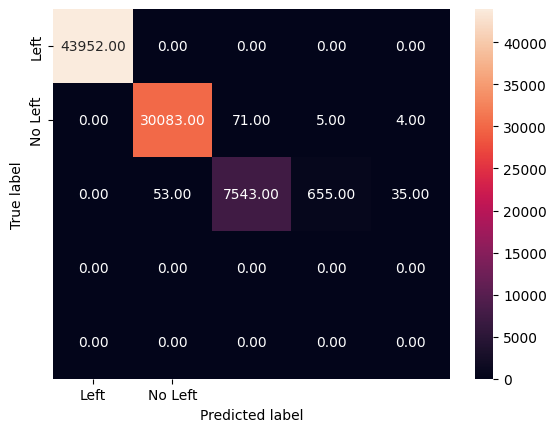

In [ ]:
tree_cm = metrics.confusion_matrix( tree_test_pred.predicted,
                                 tree_test_pred.actual )
sns.heatmap(tree_cm, annot=True,
         fmt='.2f',
         xticklabels = ["Left", "No Left"] , yticklabels = ["Left", "No Left"] )

plt.ylabel('True label')
plt.xlabel('Predicted label')

## Naive Bayes Model

#### 1) BernoulliNB

In [ ]:
from sklearn.naive_bayes import BernoulliNB

In [ ]:
bnb_clf = BernoulliNB()
bnb_clf.fit(X_train, y_train)

BernoulliNB()

In [ ]:
y_pred=bnb_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

Text(0.5, 23.52222222222222, 'Predicted label')

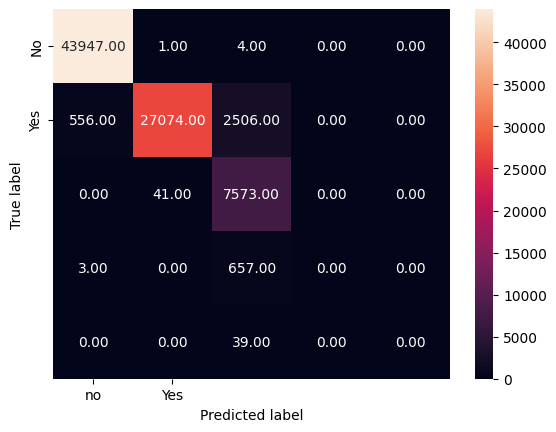

In [ ]:
nb_cm = metrics.confusion_matrix( y_test,y_pred )
sns.heatmap(nb_cm, annot=True,  fmt='.2f', xticklabels = ["no", "Yes"] , yticklabels = ["No", "Yes"] )
plt.ylabel('True label')
plt.xlabel('Predicted label')

In [ ]:
accuracy_score( y_test, y_pred )

0.9537991043798012

#### 2) GaussianNB

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
gnb_clf = GaussianNB()
gnb_clf.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred=gnb_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

Text(0.5, 23.52222222222222, 'Predicted label')

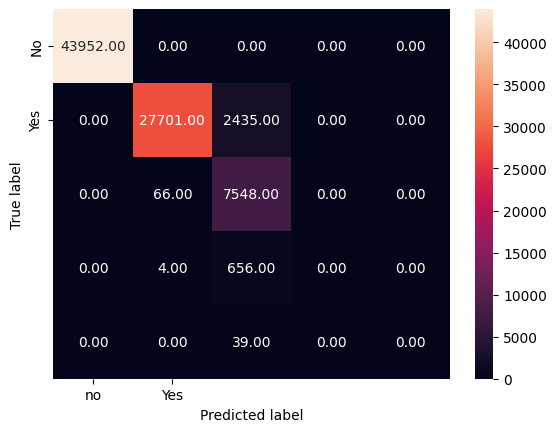

In [ ]:
nb_cm = metrics.confusion_matrix( y_test, y_pred )
sns.heatmap(nb_cm, annot=True,  fmt='.2f', xticklabels = ["no", "Yes"] , yticklabels = ["No", "Yes"] )
plt.ylabel('True label')
plt.xlabel('Predicted label')

In [ ]:
accuracy_score( y_test, y_pred )

0.9611655198359244

### Support Vector Machine (SVM)

#### 1) LinearSVC

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svm_clf = LinearSVC(random_state=0, tol=1e-5)
svm_clf.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(random_state=0, tol=1e-05)

In [ ]:
y_pred=svm_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9868569556194706

#### 2) SVC

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

model = SVC(kernel='rbf', class_weight='balanced',gamma='scale')

In [ ]:
model.fit(X_train, y_train)

SVC(class_weight='balanced')

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([2., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9190422446329535

### Stochastic Gradient Descent (SGD)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [ ]:
model = SGDClassifier(loss="hinge", penalty="l2")
model.fit(X_train, y_train)

SGDClassifier()

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([2., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.96407810584823

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic

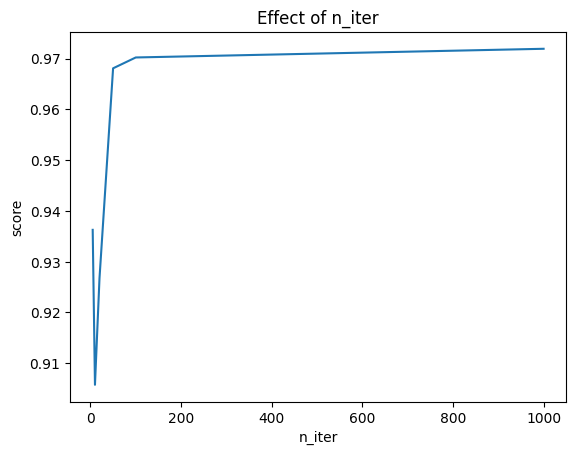

In [ ]:
n_iters = [5, 10, 20, 50, 100, 1000]
scores = []
for n_iter in n_iters:
    model = SGDClassifier(loss="hinge", penalty="l2", max_iter=n_iter)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.title("Effect of n_iter")
plt.xlabel("n_iter")
plt.ylabel("score")
plt.plot(n_iters, scores)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


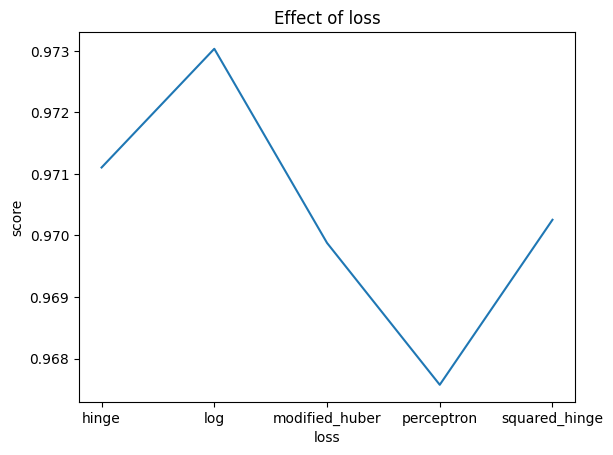

In [ ]:
# losses
losses = ["hinge", "log", "modified_huber", "perceptron", "squared_hinge"]
scores = []
for loss in losses:
    model = SGDClassifier(loss=loss, penalty="l2", max_iter=1000)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.xlabel("loss")
plt.ylabel("score")
plt.title("Effect of loss")
x = np.arange(len(losses))
plt.xticks(x, losses)
plt.plot(x, scores)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "loss" : ["hinge", "log", "squared_hinge", "modified_huber"],
    "alpha" : [0.0001, 0.001, 0.01, 0.1],
    "penalty" : ["l2", "l1", "none"],
}

model = SGDClassifier(max_iter=100)
clf = GridSearchCV(model, param_grid=params)

In [ ]:
clf.fit(X_train, y_train)
print(clf.best_score_)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic

0.9876336402082304


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
y_pred=clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9789687018361428

### Neural Network Model

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
scaler = StandardScaler()
# Fit only to the training data
scaler.fit(X_train)

StandardScaler()

In [ ]:
# Now apply the transformations to the data:
train_X = scaler.transform(X_train)
test_X = scaler.transform(X_test)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(30,30,30))
mlp.fit(train_X,y_train)

MLPClassifier(hidden_layer_sizes=(30, 30, 30))

In [ ]:
y_pred=mlp.predict(test_X)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[43952     0     0     0     0]
 [   16 30058    62     0     0]
 [   26     1  7587     0     0]
 [    0     0   660     0     0]
 [    0     0    39     0     0]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     43952
         1.0       1.00      1.00      1.00     30136
         2.0       0.91      1.00      0.95      7614
         3.0       0.00      0.00      0.00       660
         4.0       0.00      0.00      0.00        39

    accuracy                           0.99     82401
   macro avg       0.58      0.60      0.59     82401
weighted avg       0.98      0.99      0.99     82401



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
mlp.coefs_

[array([[ 1.65269536e-01,  2.55422571e-01, -5.23320092e-02,
          2.10192109e-01,  3.42647740e-01,  2.71713163e-01,
         -1.51871430e-01, -3.87588739e-01, -2.85058957e-02,
         -1.05022056e-01,  1.02628822e-01,  2.88772340e-01,
          3.97531962e-02, -2.28134736e-01,  4.56141760e-01,
         -5.77285956e-01,  2.24655602e-01, -3.33549445e-02,
          7.07498082e-02, -4.90778803e-02,  1.08172927e-01,
          2.81906994e-01,  3.29608554e-01, -2.66325791e-01,
          3.56680870e-01, -1.81737188e-01, -6.49651023e-02,
          4.82432200e-02,  3.08038783e-01,  7.39143275e-02],
        [-4.68034264e-01, -5.20410266e-01,  4.18401349e-01,
         -9.34375680e-03, -3.56696430e-01,  5.08776599e-01,
          4.68176027e-02,  2.92179431e-01, -1.91575873e-01,
          2.68892341e-01,  4.61872279e-01,  3.85579827e-01,
         -2.15906778e-01,  7.60502685e-02, -3.73426310e-01,
          5.42595979e-01, -5.02103983e-01, -3.89226084e-01,
          4.98706684e-01, -2.91996431e-

In [ ]:
accuracy_score( y_test, y_pred )

0.990242836858776

## Combine Model Predictions Into Ensemble Predictions

The three most popular methods for combining the predictions from different models are:

Bagging-> Building multiple models (typically of the same type) from different subsamples of the training dataset.

Boosting-> Building multiple models (typically of the same type) each of which learns to fix the prediction errors of a prior model in the chain.

Voting-> Building multiple models (typically of differing types) and simple statistics (like calculating the mean) are used to combine predictions.

### Bagging Algorithms

Bootstrap Aggregation or bagging involves taking multiple samples from your training dataset (with replacement) and training a model for each sample.

The final output prediction is averaged across the predictions of all of the sub-models.

The three bagging models covered in this section are as follows:

1) Bagged Decision Trees

2) Random Forest

3) Extra Trees

#### 1. Bagged Decision Trees
Bagging performs best with algorithms that have high variance. A popular example are decision trees, often constructed without pruning.

In [ ]:
from sklearn import model_selection
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
seed = 7
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
cart = DecisionTreeClassifier()
num_trees = 100
model = BaggingClassifier(base_estimator=cart, n_estimators=num_trees, random_state=seed)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/en

0.9992111753569354


In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=7)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9912379704129805

#### 2. Random Forest
Random forest is an extension of bagged decision trees.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
seed = 7
num_trees = 100
max_features = 3
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
model = RandomForestClassifier(n_estimators=num_trees, max_features=max_features)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.9993689408745992


In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(max_features=3)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9912379704129805

#### 3. Extra Trees
Extra Trees are another modification of bagging where random trees are constructed from samples of the training dataset.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
seed = 7
num_trees = 100
max_features = 7
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
model = ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.9992839923635435


In [ ]:
model.fit(X_train, y_train)

ExtraTreesClassifier(max_features=7)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9912379704129805

### Boosting Algorithms

Boosting ensemble algorithms creates a sequence of models that attempt to correct the mistakes of the models before them in the sequence.

Once created, the models make predictions which may be weighted by their demonstrated accuracy and the results are combined to create a final output prediction.

The two most common boosting ensemble machine learning algorithms are:

1) AdaBoost

2) Stochastic Gradient Boosting

#### 1. AdaBoost

AdaBoost was perhaps the first successful boosting ensemble algorithm. It generally works by weighting instances in the dataset by how easy or difficult they are to classify, allowing the algorithm to pay or or less attention to them in the construction of subsequent models.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
seed = 7
num_trees = 30
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
model = AdaBoostClassifier(n_estimators=num_trees, random_state=seed)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.9984102177367955


In [ ]:
model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=30, random_state=7)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9901336148833145

#### 2. Stochastic Gradient Boosting
Stochastic Gradient Boosting (also called Gradient Boosting Machines) are one of the most sophisticated ensemble techniques. It is also a technique that is proving to be perhaps of the the best techniques available for improving performance via ensembles.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
seed = 7
num_trees = 100
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
model = GradientBoostingClassifier(n_estimators=num_trees, random_state=seed)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.9990412783348235


In [ ]:
model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=7)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.990776810961032

### Voting Ensemble

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

The predictions of the sub-models can be weighted, but specifying the weights for classifiers manually or even heuristically is difficult. More advanced methods can learn how to best weight the predictions from submodels, but this is called stacking (stacked generalization) and is currently not provided in scikit-learn.

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

In [ ]:
seed = 7
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
# create the sub models
estimators = []
model1 = LogisticRegression()
estimators.append(('logistic', model1))
model2 = DecisionTreeClassifier()
estimators.append(('cart', model2))
model3 = SVC()
estimators.append(('svm', model3))
# create the ensemble model
ensemble = VotingClassifier(estimators)
results = model_selection.cross_val_score(ensemble, X_train, y_train, cv=kfold)
print(results.mean())

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.9962014945989919


In [ ]:
ensemble.fit(X_train, y_train)

In [ ]:
y_pred=ensemble.predict(X_test)
y_pred

In [ ]:
accuracy_score( y_test, y_pred )

# Save Model

In [ ]:
import pickle
# Saving model to disk of random forest
pickle.dump(lr_clf, open('model.pkl','wb'))

# Load Model and Predict

In [ ]:
import pickle
model=pickle.load(open('model.pkl', 'rb'))
model.predict([[1,0,0,229,0.06,0.00,0.04,10,0,0,21,0,0.04,0.00,0]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1.])

# **NETWORK INTRUSION DETECTION SYSTEM**



# Multinomial Classification (normal or DOS or PROBE or R2L or U2R)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
import itertools
import seaborn as sns

import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

In [ ]:
from sklearn import datasets
from sklearn.feature_selection import RFE
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train=pd.read_csv('/content/Train.txt',sep=',')
train=pd.read_csv('/content/drive/MyDrive/ML_Lab/train.csv',sep=',')
test=pd.read_csv('/content/Train.txt',sep=',')

In [ ]:
train.head()

,0,tcp,ftp_data,SF,491,0.1,0.2,0.3,0.4,0.5,...,0.17,0.03,0.17.1,0.00.6,0.00.7,0.00.8,0.05,0.00.9,normal,20
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15.0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19.0
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21.0
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21.0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21.0


In [ ]:
columns=["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
         "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations",
         "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate",
         "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
         "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
         "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
         "dst_host_srv_rerror_rate","attack","last_flag"]

In [ ]:
len(columns)

43

In [ ]:
train.columns=columns
test.columns=columns

In [ ]:
train = train.dropna()
train

,duration,src_bytes,dst_bytes,hot,logged_in,num_compromised,count,srv_count,serror_rate,rerror_rate,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0.0,146,0,0,0,0,13,1,0.0,0.00,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0,0,0,0,0,123,6,1.0,0.00,...,0,0,0,0,0,0,0,0,0,0
2,0.0,232,8153,0,1,0,5,5,0.2,0.00,...,0,0,0,0,0,0,0,0,0,0
3,0.0,199,420,0,1,0,30,32,0.0,0.00,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0,0,0,0,0,121,19,0.0,1.00,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82396,0.0,0,0,0,0,0,103,14,1.0,0.00,...,0,0,0,0,0,0,0,0,0,0
82397,0.0,0,0,0,0,0,239,2,1.0,0.00,...,0,0,0,0,0,0,0,0,0,0
82398,2.0,54540,0,0,1,0,2,2,0.0,0.00,...,0,0,0,0,0,0,0,0,0,0
82399,0.0,0,0,0,0,0,16,16,0.0,0.69,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0,146,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,232,8153,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,199,420,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82397,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
82398,2,2194619,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
82399,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
82400,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15.0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19.0
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21.0
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21.0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21.0


In [ ]:
test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15.0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19.0
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21.0
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21.0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21.0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82402 entries, 0 to 82401
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     82402 non-null  int64  
 1   protocol_type                82402 non-null  object 
 2   service                      82402 non-null  object 
 3   flag                         82402 non-null  object 
 4   src_bytes                    82402 non-null  int64  
 5   dst_bytes                    82402 non-null  int64  
 6   land                         82402 non-null  int64  
 7   wrong_fragment               82402 non-null  int64  
 8   urgent                       82402 non-null  int64  
 9   hot                          82402 non-null  int64  
 10  num_failed_logins            82402 non-null  int64  
 11  logged_in                    82402 non-null  int64  
 12  num_compromised              82402 non-null  int64  
 13  root_shell      

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82402 entries, 0 to 82401
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     82402 non-null  int64  
 1   protocol_type                82402 non-null  object 
 2   service                      82402 non-null  object 
 3   flag                         82402 non-null  object 
 4   src_bytes                    82402 non-null  int64  
 5   dst_bytes                    82402 non-null  int64  
 6   land                         82402 non-null  int64  
 7   wrong_fragment               82402 non-null  int64  
 8   urgent                       82402 non-null  int64  
 9   hot                          82402 non-null  int64  
 10  num_failed_logins            82402 non-null  int64  
 11  logged_in                    82402 non-null  int64  
 12  num_compromised              82402 non-null  int64  
 13  root_shell      

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,82402.0,285.344506,2.589558e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,82402.0,43679.117983,5.373193e+06,0.0,0.00,44.00,276.00,1.167519e+09
dst_bytes,82402.0,23860.796291,4.772220e+06,0.0,0.00,0.00,503.00,1.309937e+09
land,82402.0,0.000182,1.349087e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,82402.0,0.022694,2.542240e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,82402.0,0.000049,1.101614e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,82402.0,0.193139,2.078925e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,82402.0,0.001129,4.446187e-02,0.0,0.00,0.00,0.00,4.000000e+00
logged_in,82402.0,0.394675,4.887837e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,82402.0,0.306461,2.813050e+01,0.0,0.00,0.00,0.00,7.479000e+03


In attack_class normal means 0, DOS means 1, PROBE means 2, R2L means 3 and U2R means 4.

In [ ]:
train.loc[train.attack=='normal','attack_class']=0

train.loc[(train.attack=='back') | (train.attack=='land') | (train.attack=='pod') | (train.attack=='neptune') |
         (train.attack=='smurf') | (train.attack=='teardrop') | (train.attack=='apache2') | (train.attack=='udpstorm') |
         (train.attack=='processtable') | (train.attack=='worm') | (train.attack=='mailbomb'),'attack_class']=1

train.loc[(train.attack=='satan') | (train.attack=='ipsweep') | (train.attack=='nmap') | (train.attack=='portsweep') |
          (train.attack=='mscan') | (train.attack=='saint'),'attack_class']=2

train.loc[(train.attack=='guess_passwd') | (train.attack=='ftp_write') | (train.attack=='imap') | (train.attack=='phf') |
          (train.attack=='multihop') | (train.attack=='warezmaster') | (train.attack=='warezclient') | (train.attack=='spy') |
          (train.attack=='xlock') | (train.attack=='xsnoop') | (train.attack=='snmpguess') | (train.attack=='snmpgetattack') |
          (train.attack=='httptunnel') | (train.attack=='sendmail') | (train.attack=='named'),'attack_class']=3

train.loc[(train.attack=='buffer_overflow') | (train.attack=='loadmodule') | (train.attack=='rootkit') | (train.attack=='perl') |
          (train.attack=='sqlattack') | (train.attack=='xterm') | (train.attack=='ps'),'attack_class']=4

In [ ]:
test.loc[test.attack=='normal','attack_class']=0

test.loc[(test.attack=='back') | (test.attack=='land') | (test.attack=='pod') | (test.attack=='neptune') |
         (test.attack=='smurf') | (test.attack=='teardrop') | (test.attack=='apache2') | (test.attack=='udpstorm') |
         (test.attack=='processtable') | (test.attack=='worm') | (test.attack=='mailbomb'),'attack_class']=1

test.loc[(test.attack=='satan') | (test.attack=='ipsweep') | (test.attack=='nmap') | (test.attack=='portsweep') |
          (test.attack=='mscan') | (test.attack=='saint'),'attack_class']=2

test.loc[(test.attack=='guess_passwd') | (test.attack=='ftp_write') | (test.attack=='imap') | (test.attack=='phf') |
          (test.attack=='multihop') | (test.attack=='warezmaster') | (test.attack=='warezclient') | (test.attack=='spy') |
          (test.attack=='xlock') | (test.attack=='xsnoop') | (test.attack=='snmpguess') | (test.attack=='snmpgetattack') |
          (test.attack=='httptunnel') | (test.attack=='sendmail') | (test.attack=='named'),'attack_class']=3

test.loc[(test.attack=='buffer_overflow') | (test.attack=='loadmodule') | (test.attack=='rootkit') | (test.attack=='perl') |
          (test.attack=='sqlattack') | (test.attack=='xterm') | (test.attack=='ps'),'attack_class']=4

In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,last_flag,attack_class
0,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15.0,0.0
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19.0,1.0
2,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21.0,0.0
3,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21.0,0.0
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21.0,1.0


In [ ]:
train.shape

(82402, 44)

### Exporting pandas profiling output to html file

### Basic Exploratory Analysis

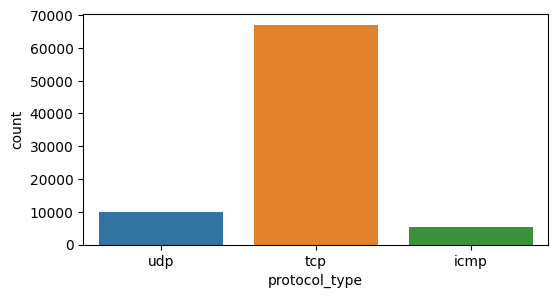

In [ ]:
# Protocol type distribution
plt.figure(figsize=(6,3))
sns.countplot(x="protocol_type", data=train)
plt.show()

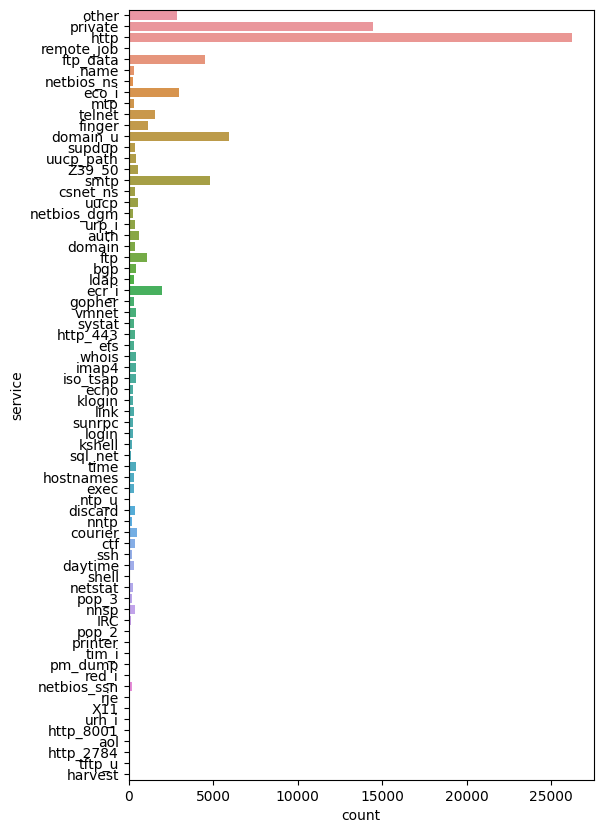

In [ ]:
# service distribution
plt.figure(figsize=(6,10))
sns.countplot(y="service", data=train)
plt.show()

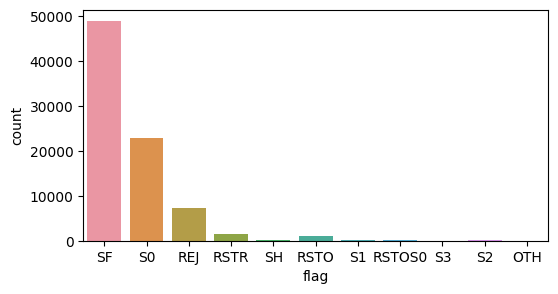

In [ ]:
# flag distribution
plt.figure(figsize=(6,3))
sns.countplot(x="flag", data=train)
plt.show()

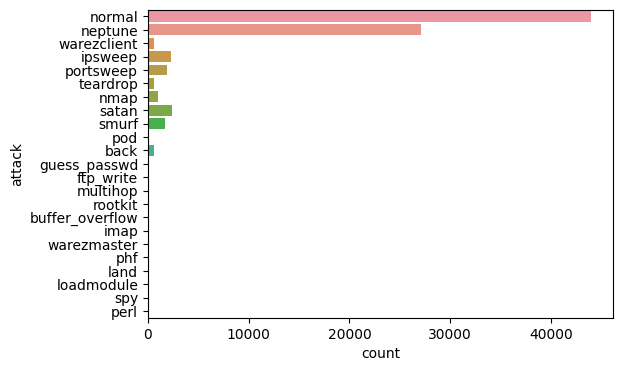

In [ ]:
# attack distribution
plt.figure(figsize=(6,4))
sns.countplot(y="attack", data=train)
plt.show()

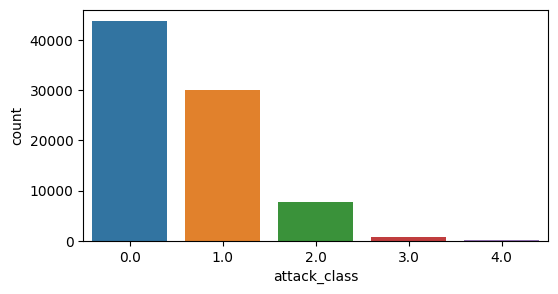

In [ ]:
# attack class distribution
plt.figure(figsize=(6,3))
sns.countplot(x="attack_class", data=train)
plt.show()

#### identifying relationships (between Y & numerical independent variables by comparing means)

In [ ]:
train.groupby('attack_class').mean().T

<ipython-input-24-13d5e93db5ff>:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  train.groupby('attack_class').mean().T


attack_class,0.0,1.0,2.0,3.0,4.0
duration,171.128640,0.005243,2050.988311,563.254545,86.692308
src_bytes,11134.217783,1183.431577,378411.744944,292340.357576,1025.230769
dst_bytes,4347.766950,170.587205,224627.442868,90102.119697,4172.256410
land,0.000114,0.000332,0.000000,0.000000,0.000000
wrong_fragment,0.000000,0.062052,0.000000,0.000000,0.000000
urgent,0.000068,0.000000,0.000000,0.000000,0.025641
hot,0.213710,0.040118,0.002101,7.936364,1.512821
num_failed_logins,0.001342,0.000000,0.000525,0.043939,0.025641
logged_in,0.709683,0.021005,0.007355,0.919697,0.871795
num_compromised,0.558609,0.019312,0.000788,0.090909,1.358974


##### Observations:
- The length of time duration of connection for attack is higher than  normal.
- Wrong fragments in the connection is only present in attack.
- Number of outbound commands in an ftp session  are 0 in both normal and attack.

In [ ]:
numeric_var_names=[key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['float64', 'int64', 'float32', 'int32']]
cat_var_names=[key for key in dict(train.dtypes) if dict(train.dtypes)[key] in ['object', 'O']]

In [ ]:
numeric_var_names

['duration',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'last_flag',
 'attack_class']

In [ ]:
cat_var_names

['protocol_type', 'service', 'flag', 'attack']

In [ ]:
train_num=train[numeric_var_names]
test_num=test[numeric_var_names]
train_num.head(5)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,last_flag,attack_class
0,0,146,0,0,0,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,15.0,0.0
1,0,0,0,0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,19.0,1.0
2,0,232,8153,0,0,0,0,0,1,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,21.0,0.0
3,0,199,420,0,0,0,0,0,1,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,21.0,0.0
4,0,0,0,0,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,21.0,1.0


In [ ]:
train_cat=train[cat_var_names]
test_cat=test[cat_var_names]
train_cat.head(5)

,protocol_type,service,flag,attack
0,udp,other,SF,normal
1,tcp,private,S0,neptune
2,tcp,http,SF,normal
3,tcp,http,SF,normal
4,tcp,private,REJ,neptune


### Data Audit Report

In [ ]:
# Creating Data audit Report
def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.min(), x.dropna().quantile(0.01), x.dropna().quantile(0.05),
                      x.dropna().quantile(0.10),x.dropna().quantile(0.25),x.dropna().quantile(0.50),x.dropna().quantile(0.75), x.dropna().quantile(0.90),
                      x.dropna().quantile(0.95), x.dropna().quantile(0.99),x.max()],
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX'])

num_summary=train_num.apply(lambda x: var_summary(x)).T

In [ ]:
num_summary

,N,NMISS,SUM,MEAN,MEDIAN,STD,VAR,MIN,P1,P5,P10,P25,P50,P75,P90,P95,P99,MAX
duration,82402.0,0.0,2.351296e+07,285.344506,0.00,2.589558e+03,6.705810e+06,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,4.00,9414.99,4.290800e+04
src_bytes,82402.0,0.0,3.599247e+09,43679.117983,44.00,5.373193e+06,2.887120e+13,0.0,0.0,0.00,0.00,0.00,44.00,276.00,848.00,1480.00,54540.00,1.167519e+09
dst_bytes,82402.0,0.0,1.966177e+09,23860.796291,0.00,4.772220e+06,2.277409e+13,0.0,0.0,0.00,0.00,0.00,0.00,503.00,3338.00,8314.00,25519.00,1.309937e+09
land,82402.0,0.0,1.500000e+01,0.000182,0.00,1.349087e-02,1.820035e-04,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.000000e+00
wrong_fragment,82402.0,0.0,1.870000e+03,0.022694,0.00,2.542240e-01,6.462983e-02,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.000000e+00
urgent,82402.0,0.0,4.000000e+00,0.000049,0.00,1.101614e-02,1.213554e-04,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.000000e+00
hot,82402.0,0.0,1.591500e+04,0.193139,0.00,2.078925e+00,4.321928e+00,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,7.700000e+01
num_failed_logins,82402.0,0.0,9.300000e+01,0.001129,0.00,4.446187e-02,1.976858e-03,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,4.000000e+00
logged_in,82402.0,0.0,3.252200e+04,0.394675,0.00,4.887837e-01,2.389095e-01,0.0,0.0,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.000000e+00
num_compromised,82402.0,0.0,2.525300e+04,0.306461,0.00,2.813050e+01,7.913249e+02,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,7.479000e+03


In [ ]:
num_summary.to_csv('num_summary.csv')

### Handling Outlier

In [ ]:
#Handling Outliers
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.99))
    x = x.clip(lower=x.quantile(0.01))
    return x

train_num=train_num.apply(outlier_capping)

#### No missing in train dataset . So , Missing treatment not required .

In [ ]:
def cat_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.value_counts()],
                  index=['N', 'NMISS', 'ColumnsNames'])

cat_summary=train_cat.apply(cat_summary)

In [ ]:
cat_summary

,protocol_type,service,flag,attack
N,82402,82402,82402,82401
NMISS,0,0,0,1
ColumnsNames,tcp 67130 udp 9891 icmp 5381 Name...,http 26211 private 14480 domain_u...,SF 48950 S0 22931 REJ 730...,normal 43952 neptune 27...


### Dummy Variable Creation

In [ ]:
# An utility function to create dummy variable
def create_dummies( df, colname ):
    col_dummies = pd.get_dummies(df[colname], prefix=colname, drop_first=True)
    df = pd.concat([df, col_dummies], axis=1)
    df.drop( colname, axis = 1, inplace = True )
    return(df)

In [ ]:
#for c_feature in categorical_features
for c_feature in ['protocol_type', 'service', 'flag', 'attack']:
    train_cat = create_dummies(train_cat,c_feature)
    test_cat = create_dummies(test_cat,c_feature)
train_cat.head()

,protocol_type_tcp,protocol_type_udp,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Final file for analysis

In [ ]:
train_new = pd.concat([train_num, train_cat], axis=1)
test_new = pd.concat([test_num, test_cat], axis=1)
train_new.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0.0,146,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,232,8153,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0.0,199,420,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# correlation matrix (ranges from 1 to -1)
corrm=train_new.corr()
corrm

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
duration,1.000000,0.009598,0.037501,NaN,NaN,NaN,0.016590,NaN,-0.064274,0.066760,...,-0.000804,-0.005277,0.406162,-0.000497,-0.024144,-0.020316,0.000772,-0.011755,0.032092,-0.001582
src_bytes,0.009598,1.000000,0.130359,NaN,NaN,NaN,0.489412,NaN,0.163903,0.598123,...,-0.000964,0.002676,-0.022180,-0.001323,-0.029136,-0.002923,-0.000688,-0.013849,0.045260,-0.002041
dst_bytes,0.037501,0.130359,1.000000,NaN,NaN,NaN,0.149697,NaN,0.421203,0.234831,...,0.010779,-0.013369,-0.052885,0.008521,-0.060643,-0.051465,-0.000185,-0.029775,-0.012636,0.071098
land,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wrong_fragment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
attack_smurf,-0.020316,-0.002923,-0.051465,NaN,NaN,NaN,-0.020999,NaN,-0.118211,-0.015105,...,-0.000883,-0.005567,-0.022485,-0.001613,-0.025492,1.000000,-0.000721,-0.012400,-0.012453,-0.001908
attack_spy,0.000772,-0.000688,-0.000185,NaN,NaN,NaN,-0.000707,NaN,0.001062,-0.000508,...,-0.000030,-0.000187,-0.000757,-0.000054,-0.000858,-0.000721,1.000000,-0.000417,-0.000419,-0.000064
attack_teardrop,-0.011755,-0.013849,-0.029775,NaN,NaN,NaN,-0.012150,NaN,-0.068396,-0.008740,...,-0.000511,-0.003221,-0.013009,-0.000933,-0.014749,-0.012400,-0.000417,1.000000,-0.007205,-0.001104
attack_warezclient,0.032092,0.045260,-0.012636,NaN,NaN,NaN,0.223818,NaN,0.105349,-0.008777,...,-0.000513,-0.003235,-0.013065,-0.000937,-0.014813,-0.012453,-0.000419,-0.007205,1.000000,-0.001109


In [ ]:
corrm.to_csv('corrm.csv')

<Axes: >

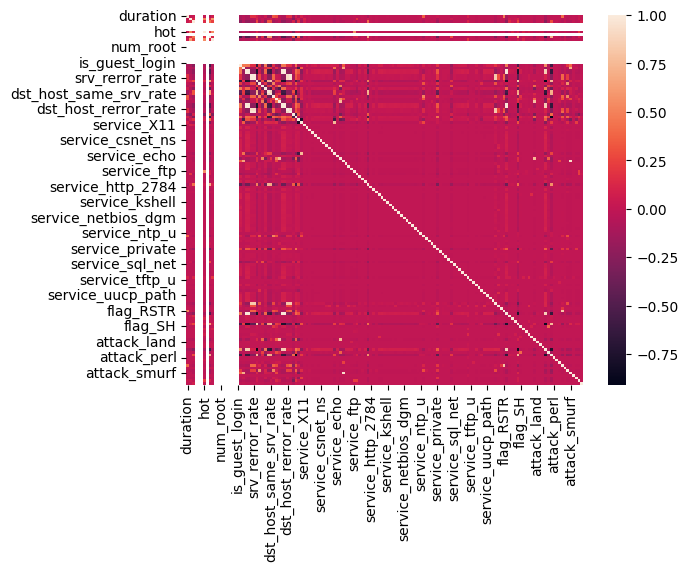

In [ ]:
# visualize correlation matrix in Seaborn using a heatmap
sns.heatmap(corrm)

#### Dropping columns based on data audit report
        - Based on low variance (near zero variance)
        - High missings (>25% missings)
        - High correlations between two numerical variables

In [ ]:
train_new.drop(columns=['land','wrong_fragment','urgent','num_failed_logins',"root_shell","su_attempted","num_root",
                        "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
                        'dst_host_rerror_rate','dst_host_serror_rate','dst_host_srv_rerror_rate','dst_host_srv_serror_rate',
                        'num_root','num_outbound_cmds','srv_rerror_rate','srv_serror_rate'], axis=1, inplace=True)

In [ ]:
train_new["attack_class"]

0        0.0
1        1.0
2        0.0
3        0.0
4        1.0
        ... 
82397    1.0
82398    0.0
82399    0.0
82400    1.0
82401    NaN
Name: attack_class, Length: 82402, dtype: float64

<Axes: >

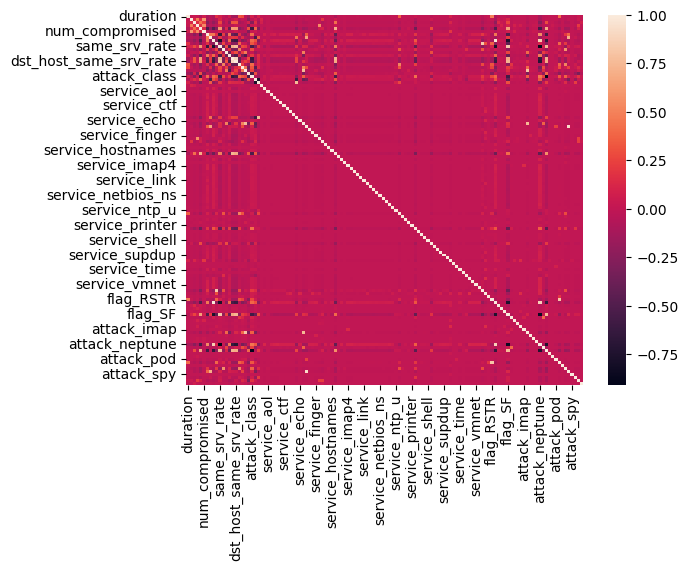

In [ ]:
sns.heatmap(train_new.corr())

#### Variable reduction using Select K-Best technique

In [ ]:
X = train_new[train_new.columns.difference(['attack_class'])]
X

,attack_buffer_overflow,attack_ftp_write,attack_guess_passwd,attack_imap,attack_ipsweep,attack_land,attack_loadmodule,attack_multihop,attack_neptune,attack_nmap,...,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,src_bytes,srv_count,srv_diff_host_rate
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,146,1,0.00
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,6,0.00
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,232,5,0.00
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,199,32,0.09
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,19,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82397,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,2,0.00
82398,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,54540,2,0.00
82399,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,16,0.00
82400,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,16,0.00


In [ ]:
X = X.dropna()
X

,attack_buffer_overflow,attack_ftp_write,attack_guess_passwd,attack_imap,attack_ipsweep,attack_land,attack_loadmodule,attack_multihop,attack_neptune,attack_nmap,...,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,src_bytes,srv_count,srv_diff_host_rate
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,146,1,0.00
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,6,0.00
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,232,5,0.00
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,199,32,0.09
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,19,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82396,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,14,0.00
82397,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,2,0.00
82398,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,54540,2,0.00
82399,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,16,0.00


In [ ]:
train_new = train_new.dropna()
train_new

,duration,src_bytes,dst_bytes,hot,logged_in,num_compromised,count,srv_count,serror_rate,rerror_rate,...,attack_phf,attack_pod,attack_portsweep,attack_rootkit,attack_satan,attack_smurf,attack_spy,attack_teardrop,attack_warezclient,attack_warezmaster
0,0.0,146,0,0,0,0,13,1,0.0,0.00,...,0,0,0,0,0,0,0,0,0,0
1,0.0,0,0,0,0,0,123,6,1.0,0.00,...,0,0,0,0,0,0,0,0,0,0
2,0.0,232,8153,0,1,0,5,5,0.2,0.00,...,0,0,0,0,0,0,0,0,0,0
3,0.0,199,420,0,1,0,30,32,0.0,0.00,...,0,0,0,0,0,0,0,0,0,0
4,0.0,0,0,0,0,0,121,19,0.0,1.00,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82396,0.0,0,0,0,0,0,103,14,1.0,0.00,...,0,0,0,0,0,0,0,0,0,0
82397,0.0,0,0,0,0,0,239,2,1.0,0.00,...,0,0,0,0,0,0,0,0,0,0
82398,2.0,54540,0,0,1,0,2,2,0.0,0.00,...,0,0,0,0,0,0,0,0,0,0
82399,0.0,0,0,0,0,0,16,16,0.0,0.69,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_new = SelectKBest(f_classif, k=15).fit(X, train_new['attack_class'] )

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [ ]:
X_new.get_support()

array([False, False, False, False, False, False, False, False,  True,
       False,  True, False, False, False, False, False,  True, False,
       False, False, False, False,  True, False, False, False,  True,
        True,  True,  True, False, False, False, False, False, False,
        True, False, False, False,  True, False, False,  True,  True,
       False, False, False, False,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [ ]:
X_new.scores_

array([1.02772133e+02, 2.22933626e+01, 1.34163895e+02, 3.56822650e+01,
       1.43398884e+04, 8.67408504e+00, 1.78325437e+01, 2.67552556e+01,
       2.29799666e+05, 4.89328228e+03,            inf, 8.91412618e+00,
       1.33727983e+01, 1.03596438e+02, 1.09672583e+04, 4.46135750e+01,
       1.52561871e+04, 1.59050401e+03, 8.91412618e+00, 5.19111273e+02,
       2.84020847e+03, 6.24891094e+01, 2.75026325e+04, 5.25258684e+03,
       3.74021500e+03, 1.20807532e+04, 1.45662336e+04, 1.80235279e+04,
       4.38866961e+04, 4.51996955e+04, 1.19074190e+04, 1.53834317e+03,
       1.91905805e+03, 3.97369547e+02, 3.10036747e+02, 6.53196045e+03,
       7.26079704e+04, 1.02572843e+02, 2.79637284e+01, 1.19859142e+01,
       7.26361191e+04, 7.40853027e+02, 5.46650359e+01, 2.09062528e+04,
       3.74384637e+04, 1.79297701e+02, 3.46005813e+03, 2.50594980e+03,
       5.25037025e+03, 8.74053173e+04, 6.77859699e+04, 1.77408976e+01,
       4.71104076e+02, 4.45652687e+00, 1.93489080e+02, 3.72852743e+02,
      

#**Feature Extraction**

In [ ]:
# capturing the important variables
KBest_features=X.columns[X_new.get_support()]
KBest_features

Index(['attack_neptune', 'attack_normal', 'attack_satan', 'count',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_same_srv_rate', 'dst_host_srv_count', 'flag_S0', 'flag_SF',
       'last_flag', 'logged_in', 'same_srv_rate', 'serror_rate',
       'service_http'],
      dtype='object')

### Final list of variable selected for the model building using Select KBest

attack_neptune, attack_normal, attack_satan, count, dst_host_diff_srv_rate, dst_host_same_src_port_rate, dst_host_same_srv_rate, dst_host_srv_count, flag_S0, flag_SF, last_flag, logged_in, same_srv_rate, serror_rate, service_http

In [ ]:
train=train_new
test=test_new
test_new.shape

(82402, 143)

## Model Building

In [ ]:
top_features=['attack_neptune','attack_normal','attack_satan','count','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_same_srv_rate','dst_host_srv_count','flag_S0','flag_SF','last_flag','logged_in','same_srv_rate','serror_rate','service_http']
X_train = train[top_features]

y_train = train['attack_class']
X_test = test[top_features]
y_test = test['attack_class']

In [ ]:
X_test.shape

(82402, 15)

In [ ]:
y_test = y_test.dropna()
y_test

0        0.0
1        1.0
2        0.0
3        0.0
4        1.0
        ... 
82396    1.0
82397    1.0
82398    0.0
82399    0.0
82400    1.0
Name: attack_class, Length: 82401, dtype: float64

In [ ]:
X_test = X_test.dropna()
X_test

,attack_neptune,attack_normal,attack_satan,count,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_same_srv_rate,dst_host_srv_count,flag_S0,flag_SF,last_flag,logged_in,same_srv_rate,serror_rate,service_http
0,0,1,0,13,0.60,0.88,0.00,1.0,0,1,15.0,0,0.08,0.0,0
1,1,0,0,123,0.05,0.00,0.10,26.0,1,0,19.0,0,0.05,1.0,0
2,0,1,0,5,0.00,0.03,1.00,255.0,0,1,21.0,1,1.00,0.2,1
3,0,1,0,30,0.00,0.00,1.00,255.0,0,1,21.0,1,1.00,0.0,1
4,1,0,0,121,0.07,0.00,0.07,19.0,0,0,21.0,0,0.16,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82396,1,0,0,103,0.05,0.00,0.13,34.0,1,0,18.0,0,0.14,1.0,0
82397,1,0,0,239,0.07,0.00,0.01,2.0,1,0,20.0,0,0.01,1.0,0
82398,0,1,0,2,0.12,0.18,0.18,48.0,0,1,19.0,1,1.00,0.0,0
82399,0,1,0,16,0.00,0.02,1.00,251.0,0,0,20.0,0,1.00,0.0,1


### Building logistic Regression

#### 1) LogisticRegression

In [ ]:
lr_clf = LogisticRegression(random_state=0, solver='lbfgs',multi_class='multinomial').fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred=lr_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
  from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9864200677176248

#### 2) RidgeClassifier

In [ ]:
from sklearn.linear_model import RidgeClassifier

In [ ]:
rc_clf = RidgeClassifier().fit(X_train, y_train)

In [ ]:
y_pred=rc_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9749032171939661

### K-Nearest Neighbors

#### 1) KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
k_neigh = KNeighborsClassifier(n_neighbors=3)
k_neigh.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred=k_neigh.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9864564750427786

#### 3) NearestCentroid

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.neighbors import NearestCentroid

In [ ]:
nc = NearestCentroid()
nc.fit(X_train, y_train)

NearestCentroid()

In [ ]:
y_pred=nc.predict(X_test)
y_pred

array([2., 2., 0., ..., 2., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7102705064258928

### Discriminant Analysis

#### 1) LinearDiscriminantAnalysis

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [ ]:
y_pred=lda.predict(X_test)
y_pred

array([2., 1., 0., ..., 0., 0., 1.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9488962512590866

#### 2) QuadraticDiscriminantAnalysis

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [ ]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:926: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


QuadraticDiscriminantAnalysis()

In [ ]:
y_pred=qda.predict(X_test)
y_pred

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:951: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:951: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:954: RuntimeWarning: divide by zero encountered in log
  u = np.asarray([np.sum(np.log(s)) for s in self.scalings_])


array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5333915850535794

### Decision Trees

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn import metrics
import sklearn.tree as dt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz, plot_tree
from sklearn.model_selection import GridSearchCV

In [ ]:
clf_tree = DecisionTreeClassifier( max_depth = 5)
clf_tree=clf_tree.fit( X_train, y_train )

In [ ]:
y_pred=qda.predict(X_test)
y_pred

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:951: RuntimeWarning: divide by zero encountered in power
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:951: RuntimeWarning: invalid value encountered in multiply
  X2 = np.dot(Xm, R * (S ** (-0.5)))
/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:954: RuntimeWarning: divide by zero encountered in log
  u = np.asarray([np.sum(np.log(s)) for s in self.scalings_])


array([0., 0., 0., ..., 0., 0., 0.])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.5333915850535794

#### Fine Tuning the parameters

In [ ]:
param_grid = {'max_depth': np.arange(3, 9),
             'max_features': np.arange(3,9)}

In [ ]:
tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 5)
tree.fit( X_train, y_train )

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': array([3, 4, 5, 6, 7, 8]),
                         'max_features': array([3, 4, 5, 6, 7, 8])})

In [ ]:
tree.best_score_

0.9983009870736705

In [ ]:
tree.best_estimator_

DecisionTreeClassifier(max_depth=8, max_features=8)

In [ ]:
tree.best_params_

{'max_depth': 8, 'max_features': 8}

### Building Final Decision Tree Model

In [ ]:
clf_tree = DecisionTreeClassifier( max_depth = 8, max_features=8 )
clf_tree.fit( X_train, y_train )

DecisionTreeClassifier(max_depth=8, max_features=8)

#### Feature Relative Importance

In [ ]:
clf_tree.feature_importances_

array([5.98794012e-01, 3.09715491e-01, 1.61758844e-02, 1.99865017e-02,
       6.26206199e-04, 2.10226234e-02, 7.17780267e-03, 3.06982416e-03,
       1.24387826e-04, 1.53165849e-02, 4.15409278e-03, 3.20586535e-03,
       0.00000000e+00, 2.13119663e-04, 4.17604405e-04])

In [ ]:
# summarize the selection of the attributes
import itertools
feature_map = [(i, v) for i, v in itertools.zip_longest(X_train.columns, clf_tree.feature_importances_)]

feature_map

[('attack_neptune', 0.5987940115083271),
 ('attack_normal', 0.3097154911144042),
 ('attack_satan', 0.016175884351299758),
 ('count', 0.019986501691313868),
 ('dst_host_diff_srv_rate', 0.0006262061985899269),
 ('dst_host_same_src_port_rate', 0.021022623388318958),
 ('dst_host_same_srv_rate', 0.007177802666175966),
 ('dst_host_srv_count', 0.003069824163895729),
 ('flag_S0', 0.00012438782638921062),
 ('flag_SF', 0.015316584891361324),
 ('last_flag', 0.004154092782457747),
 ('logged_in', 0.0032058653499635065),
 ('same_srv_rate', 0.0),
 ('serror_rate', 0.00021311966271669828),
 ('service_http', 0.00041760440478605534)]

In [ ]:
Feature_importance = pd.DataFrame(feature_map, columns=['Feature', 'importance'])
Feature_importance.sort_values('importance', inplace=True, ascending=False)
Feature_importance

,Feature,importance
0,attack_neptune,0.598794
1,attack_normal,0.309715
5,dst_host_same_src_port_rate,0.021023
3,count,0.019987
2,attack_satan,0.016176
9,flag_SF,0.015317
6,dst_host_same_srv_rate,0.007178
10,last_flag,0.004154
11,logged_in,0.003206
7,dst_host_srv_count,0.003070


In [ ]:
tree_test_pred = pd.DataFrame( { 'actual':  y_test,
                            'predicted': clf_tree.predict( X_test ) } )

In [ ]:
tree_test_pred.sample( n = 10 )

,actual,predicted
48912,1.0,1.0
71978,1.0,1.0
72369,2.0,2.0
61297,0.0,0.0
20419,2.0,2.0
33127,1.0,1.0
42951,1.0,1.0
40843,2.0,2.0
34289,0.0,0.0
56847,0.0,0.0


In [ ]:
accuracy_score( tree_test_pred.actual, tree_test_pred.predicted )

0.9900122571328018

Text(0.5, 23.52222222222222, 'Predicted label')

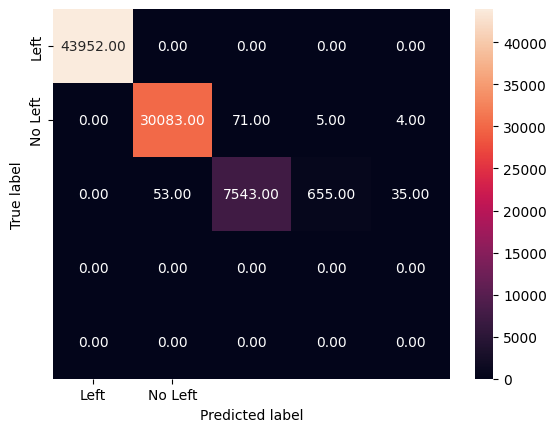

In [ ]:
tree_cm = metrics.confusion_matrix( tree_test_pred.predicted,
                                 tree_test_pred.actual )
sns.heatmap(tree_cm, annot=True,
         fmt='.2f',
         xticklabels = ["Left", "No Left"] , yticklabels = ["Left", "No Left"] )

plt.ylabel('True label')
plt.xlabel('Predicted label')

## Naive Bayes Model

#### 1) BernoulliNB

In [ ]:
from sklearn.naive_bayes import BernoulliNB

In [ ]:
bnb_clf = BernoulliNB()
bnb_clf.fit(X_train, y_train)

BernoulliNB()

In [ ]:
y_pred=bnb_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

Text(0.5, 23.52222222222222, 'Predicted label')

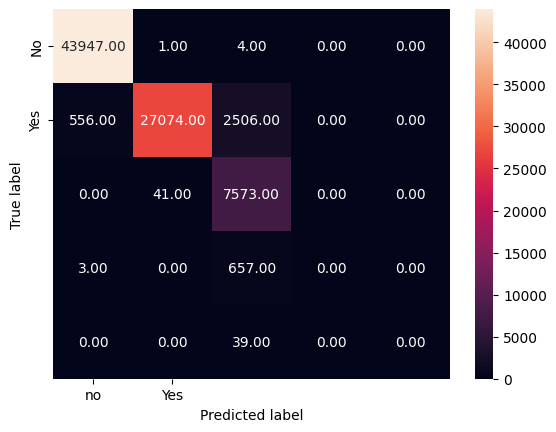

In [ ]:
nb_cm = metrics.confusion_matrix( y_test,y_pred )
sns.heatmap(nb_cm, annot=True,  fmt='.2f', xticklabels = ["no", "Yes"] , yticklabels = ["No", "Yes"] )
plt.ylabel('True label')
plt.xlabel('Predicted label')

In [ ]:
accuracy_score( y_test, y_pred )

0.9537991043798012

#### 2) GaussianNB

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
gnb_clf = GaussianNB()
gnb_clf.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred=gnb_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

Text(0.5, 23.52222222222222, 'Predicted label')

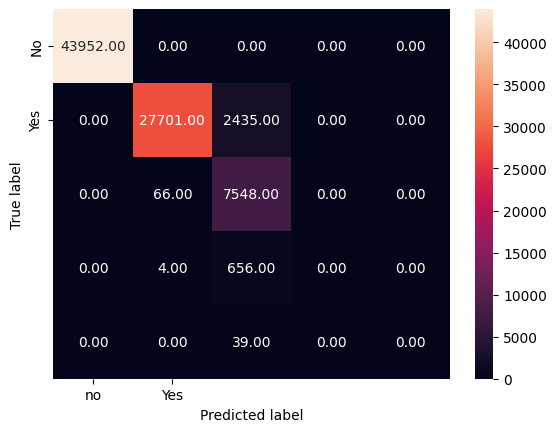

In [ ]:
nb_cm = metrics.confusion_matrix( y_test, y_pred )
sns.heatmap(nb_cm, annot=True,  fmt='.2f', xticklabels = ["no", "Yes"] , yticklabels = ["No", "Yes"] )
plt.ylabel('True label')
plt.xlabel('Predicted label')

In [ ]:
accuracy_score( y_test, y_pred )

0.9611655198359244

### Support Vector Machine (SVM)

#### 1) LinearSVC

In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
svm_clf = LinearSVC(random_state=0, tol=1e-5)
svm_clf.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(random_state=0, tol=1e-05)

In [ ]:
y_pred=svm_clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9868569556194706

#### 2) SVC

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

model = SVC(kernel='rbf', class_weight='balanced',gamma='scale')

In [ ]:
model.fit(X_train, y_train)

SVC(class_weight='balanced')

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([2., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9190422446329535

### Stochastic Gradient Descent (SGD)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [ ]:
model = SGDClassifier(loss="hinge", penalty="l2")
model.fit(X_train, y_train)

SGDClassifier()

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([2., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.96407810584823

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic

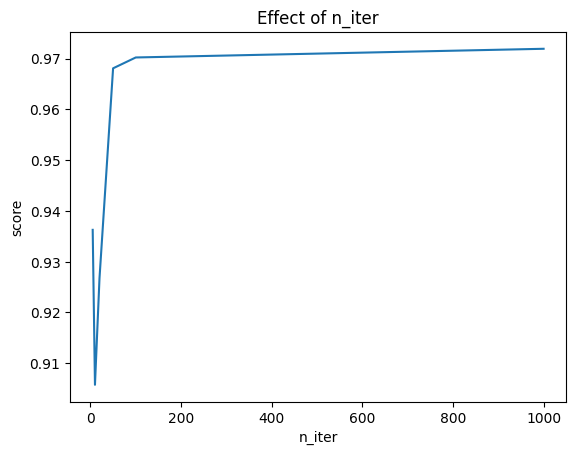

In [ ]:
n_iters = [5, 10, 20, 50, 100, 1000]
scores = []
for n_iter in n_iters:
    model = SGDClassifier(loss="hinge", penalty="l2", max_iter=n_iter)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.title("Effect of n_iter")
plt.xlabel("n_iter")
plt.ylabel("score")
plt.plot(n_iters, scores)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


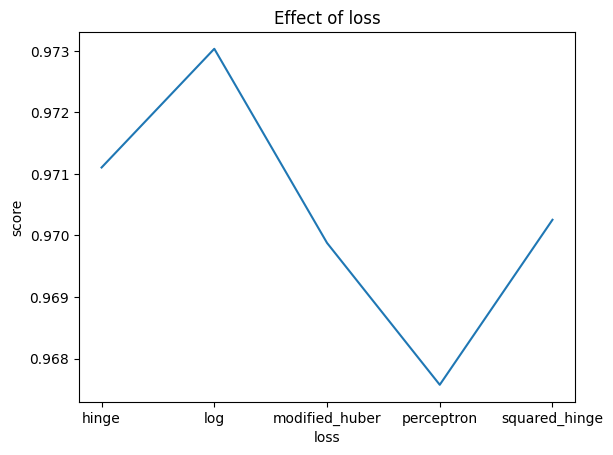

In [ ]:
# losses
losses = ["hinge", "log", "modified_huber", "perceptron", "squared_hinge"]
scores = []
for loss in losses:
    model = SGDClassifier(loss=loss, penalty="l2", max_iter=1000)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.xlabel("loss")
plt.ylabel("score")
plt.title("Effect of loss")
x = np.arange(len(losses))
plt.xticks(x, losses)
plt.plot(x, scores)

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    "loss" : ["hinge", "log", "squared_hinge", "modified_huber"],
    "alpha" : [0.0001, 0.001, 0.01, 0.1],
    "penalty" : ["l2", "l1", "none"],
}

model = SGDClassifier(max_iter=100)
clf = GridSearchCV(model, param_grid=params)

In [ ]:
clf.fit(X_train, y_train)
print(clf.best_score_)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic

0.9876336402082304


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [ ]:
y_pred=clf.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9789687018361428

### Neural Network Model

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
scaler = StandardScaler()
# Fit only to the training data
scaler.fit(X_train)

StandardScaler()

In [ ]:
# Now apply the transformations to the data:
train_X = scaler.transform(X_train)
test_X = scaler.transform(X_test)

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(30,30,30))
mlp.fit(train_X,y_train)

MLPClassifier(hidden_layer_sizes=(30, 30, 30))

In [ ]:
y_pred=mlp.predict(test_X)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[43952     0     0     0     0]
 [   16 30058    62     0     0]
 [   26     1  7587     0     0]
 [    0     0   660     0     0]
 [    0     0    39     0     0]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     43952
         1.0       1.00      1.00      1.00     30136
         2.0       0.91      1.00      0.95      7614
         3.0       0.00      0.00      0.00       660
         4.0       0.00      0.00      0.00        39

    accuracy                           0.99     82401
   macro avg       0.58      0.60      0.59     82401
weighted avg       0.98      0.99      0.99     82401



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
mlp.coefs_

[array([[ 1.65269536e-01,  2.55422571e-01, -5.23320092e-02,
          2.10192109e-01,  3.42647740e-01,  2.71713163e-01,
         -1.51871430e-01, -3.87588739e-01, -2.85058957e-02,
         -1.05022056e-01,  1.02628822e-01,  2.88772340e-01,
          3.97531962e-02, -2.28134736e-01,  4.56141760e-01,
         -5.77285956e-01,  2.24655602e-01, -3.33549445e-02,
          7.07498082e-02, -4.90778803e-02,  1.08172927e-01,
          2.81906994e-01,  3.29608554e-01, -2.66325791e-01,
          3.56680870e-01, -1.81737188e-01, -6.49651023e-02,
          4.82432200e-02,  3.08038783e-01,  7.39143275e-02],
        [-4.68034264e-01, -5.20410266e-01,  4.18401349e-01,
         -9.34375680e-03, -3.56696430e-01,  5.08776599e-01,
          4.68176027e-02,  2.92179431e-01, -1.91575873e-01,
          2.68892341e-01,  4.61872279e-01,  3.85579827e-01,
         -2.15906778e-01,  7.60502685e-02, -3.73426310e-01,
          5.42595979e-01, -5.02103983e-01, -3.89226084e-01,
          4.98706684e-01, -2.91996431e-

In [ ]:
accuracy_score( y_test, y_pred )

0.990242836858776

## Combine Model Predictions Into Ensemble Predictions

The three most popular methods for combining the predictions from different models are:

Bagging-> Building multiple models (typically of the same type) from different subsamples of the training dataset.

Boosting-> Building multiple models (typically of the same type) each of which learns to fix the prediction errors of a prior model in the chain.

Voting-> Building multiple models (typically of differing types) and simple statistics (like calculating the mean) are used to combine predictions.

### Bagging Algorithms

Bootstrap Aggregation or bagging involves taking multiple samples from your training dataset (with replacement) and training a model for each sample.

The final output prediction is averaged across the predictions of all of the sub-models.

The three bagging models covered in this section are as follows:

1) Bagged Decision Trees

2) Random Forest

3) Extra Trees

#### 1. Bagged Decision Trees
Bagging performs best with algorithms that have high variance. A popular example are decision trees, often constructed without pruning.

In [ ]:
from sklearn import model_selection
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
seed = 7
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
cart = DecisionTreeClassifier()
num_trees = 100
model = BaggingClassifier(base_estimator=cart, n_estimators=num_trees, random_state=seed)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/en

0.9992111753569354


In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=7)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9912379704129805

#### 2. Random Forest
Random forest is an extension of bagged decision trees.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
seed = 7
num_trees = 100
max_features = 3
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
model = RandomForestClassifier(n_estimators=num_trees, max_features=max_features)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.9993689408745992


In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(max_features=3)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9912379704129805

#### 3. Extra Trees
Extra Trees are another modification of bagging where random trees are constructed from samples of the training dataset.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
seed = 7
num_trees = 100
max_features = 7
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
model = ExtraTreesClassifier(n_estimators=num_trees, max_features=max_features)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.9992839923635435


In [ ]:
model.fit(X_train, y_train)

ExtraTreesClassifier(max_features=7)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9912379704129805

### Boosting Algorithms

Boosting ensemble algorithms creates a sequence of models that attempt to correct the mistakes of the models before them in the sequence.

Once created, the models make predictions which may be weighted by their demonstrated accuracy and the results are combined to create a final output prediction.

The two most common boosting ensemble machine learning algorithms are:

1) AdaBoost

2) Stochastic Gradient Boosting

#### 1. AdaBoost

AdaBoost was perhaps the first successful boosting ensemble algorithm. It generally works by weighting instances in the dataset by how easy or difficult they are to classify, allowing the algorithm to pay or or less attention to them in the construction of subsequent models.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
seed = 7
num_trees = 30
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
model = AdaBoostClassifier(n_estimators=num_trees, random_state=seed)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.9984102177367955


In [ ]:
model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=30, random_state=7)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.9901336148833145

#### 2. Stochastic Gradient Boosting
Stochastic Gradient Boosting (also called Gradient Boosting Machines) are one of the most sophisticated ensemble techniques. It is also a technique that is proving to be perhaps of the the best techniques available for improving performance via ensembles.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
seed = 7
num_trees = 100
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
model = GradientBoostingClassifier(n_estimators=num_trees, random_state=seed)
results = model_selection.cross_val_score(model, X_train, y_train, cv=kfold)
print(results.mean())

0.9990412783348235


In [ ]:
model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=7)

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0., 1., 0., ..., 0., 0., 1.])

In [ ]:
accuracy_score( y_test, y_pred )

0.990776810961032

### Voting Ensemble

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

The predictions of the sub-models can be weighted, but specifying the weights for classifiers manually or even heuristically is difficult. More advanced methods can learn how to best weight the predictions from submodels, but this is called stacking (stacked generalization) and is currently not provided in scikit-learn.

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

In [ ]:
seed = 7
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=seed)  # Set shuffle to True
# create the sub models
estimators = []
model1 = LogisticRegression()
estimators.append(('logistic', model1))
model2 = DecisionTreeClassifier()
estimators.append(('cart', model2))
model3 = SVC()
estimators.append(('svm', model3))
# create the ensemble model
ensemble = VotingClassifier(estimators)
results = model_selection.cross_val_score(ensemble, X_train, y_train, cv=kfold)
print(results.mean())

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.9962014945989919


In [ ]:
ensemble.fit(X_train, y_train)

In [ ]:
y_pred=ensemble.predict(X_test)
y_pred

In [ ]:
accuracy_score( y_test, y_pred )

# Save Model

In [ ]:
import pickle
# Saving model to disk of random forest
pickle.dump(lr_clf, open('model.pkl','wb'))

# Load Model and Predict

In [ ]:
import pickle
model=pickle.load(open('model.pkl', 'rb'))
model.predict([[1,0,0,229,0.06,0.00,0.04,10,0,0,21,0,0.04,0.00,0]])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1.])